In [73]:
from pathlib import Path
import pandas as pd
import numpy as np

# پیدا کردن root پروژه، چه notebook از root اجرا شود چه از notebooks/
cwd = Path.cwd()

if (cwd / "data" / "raw").exists():
    ROOT = cwd
elif (cwd.parent / "data" / "raw").exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError("Project root not found.")

DATA_DIR = ROOT / "data" / "raw"

SEARCH_PATH = DATA_DIR / "search_data.csv"
CITIES_PATH = DATA_DIR / "cities.csv"
EVAL_PATH = DATA_DIR / "evaluation.csv"

print("Project root:", ROOT)
print("Data dir:", DATA_DIR)

Project root: c:\Users\ASUS\pol4-hackathon
Data dir: c:\Users\ASUS\pol4-hackathon\data\raw


In [74]:
search = pd.read_csv(
    SEARCH_PATH,
    parse_dates=["log_date", "checkin"],
    low_memory=False
)

cities = pd.read_csv(CITIES_PATH)

evaluation = pd.read_csv(
    EVAL_PATH,
    parse_dates=["log_date", "checkin"],
    low_memory=False
)

print("search_data shape:", search.shape)
print("cities shape:", cities.shape)
print("evaluation shape:", evaluation.shape)

search_data shape: (3298564, 4)
cities shape: (321, 4)
evaluation shape: (65411, 4)


In [75]:
print("SEARCH DATA")
print("=" * 50)
print(search.columns.tolist())
print()
print(search.dtypes)
print()

display(search.head())

SEARCH DATA
['log_date', 'city_code', 'checkin', 'search_count']

log_date        datetime64[ns]
city_code                int64
checkin         datetime64[ns]
search_count             int64
dtype: object



,log_date,city_code,checkin,search_count
0,2023-09-04,1011,2023-11-01,5
1,2023-09-08,1011,2023-11-01,3
2,2023-09-23,1011,2023-11-01,3
3,2023-09-26,1011,2023-11-01,1
4,2023-09-29,1011,2023-11-01,1


In [76]:
print("CITIES")
print("=" * 50)
print(cities.columns.tolist())
print(cities.dtypes)
display(cities.head())

print("\nEVALUATION")
print("=" * 50)
print(evaluation.columns.tolist())
print(evaluation.dtypes)
display(evaluation.head())

CITIES
['city_code', 'province_code', 'lat', 'long']
city_code          int64
province_code      int64
lat              float64
long             float64
dtype: object


,city_code,province_code,lat,long
0,1011,149,35.881989,52.169750
1,1013,289,37.102367,58.510872
2,1053,149,36.721233,51.115971
3,1054,289,37.444752,59.105713
4,1120,987,35.691353,50.840694



EVALUATION
['log_date', 'city_code', 'checkin', 'search_count']
log_date        datetime64[ns]
city_code                int64
checkin         datetime64[ns]
search_count             int64
dtype: object


,log_date,city_code,checkin,search_count
0,2025-10-20,1011,2025-11-22,1
1,2025-10-23,1011,2025-11-22,3
2,2025-10-26,1011,2025-11-22,5
3,2025-10-29,1011,2025-11-22,3
4,2025-11-02,1011,2025-11-22,2


In [77]:
audit_dates = {
    "search_min_log_date": search["log_date"].min(),
    "search_max_log_date": search["log_date"].max(),
    "search_min_checkin": search["checkin"].min(),
    "search_max_checkin": search["checkin"].max(),
    "search_unique_log_dates": search["log_date"].nunique(),
    "search_unique_checkins": search["checkin"].nunique(),

    "eval_min_log_date": evaluation["log_date"].min(),
    "eval_max_log_date": evaluation["log_date"].max(),
    "eval_min_checkin": evaluation["checkin"].min(),
    "eval_max_checkin": evaluation["checkin"].max(),
}

for key, value in audit_dates.items():
    print(f"{key}: {value}")

search_min_log_date: 2023-09-03 00:00:00
search_max_log_date: 2025-11-21 00:00:00
search_min_checkin: 2023-11-01 00:00:00
search_max_checkin: 2025-11-21 00:00:00
search_unique_log_dates: 811
search_unique_checkins: 752
eval_min_log_date: 2025-09-24 00:00:00
eval_max_log_date: 2025-11-21 00:00:00
eval_min_checkin: 2025-11-22 00:00:00
eval_max_checkin: 2025-12-21 00:00:00


In [78]:
print("Unique cities in search_data:", search["city_code"].nunique())
print("Unique cities in cities.csv:", cities["city_code"].nunique())
print("Unique cities in evaluation:", evaluation["city_code"].nunique())

Unique cities in search_data: 321
Unique cities in cities.csv: 321
Unique cities in evaluation: 239


In [79]:
search_cities = set(search["city_code"].unique())
master_cities = set(cities["city_code"].unique())
eval_cities = set(evaluation["city_code"].unique())

print("Cities in master but NOT historical:", len(master_cities - search_cities))
print(sorted(master_cities - search_cities)[:30])

print("\nCities in historical but NOT master:", len(search_cities - master_cities))
print(sorted(search_cities - master_cities)[:30])

print("\nCities in master but NOT evaluation:", len(master_cities - eval_cities))

Cities in master but NOT historical: 0
[]

Cities in historical but NOT master: 0
[]

Cities in master but NOT evaluation: 82


In [80]:
print("SEARCH NULLS")
print(search.isna().sum())

print("\nCITIES NULLS")
print(cities.isna().sum())

print("\nEVALUATION NULLS")
print(evaluation.isna().sum())

SEARCH NULLS
log_date        0
city_code       0
checkin         0
search_count    0
dtype: int64

CITIES NULLS
city_code        0
province_code    0
lat              0
long             0
dtype: int64

EVALUATION NULLS
log_date        0
city_code       0
checkin         0
search_count    0
dtype: int64


In [81]:
grain = ["log_date", "city_code", "checkin"]

duplicate_grain_rows = search.duplicated(
    subset=grain,
    keep=False
)

print("Rows involved in duplicate grain keys:",
      duplicate_grain_rows.sum())

print("Number of duplicated grain keys:",
      search.duplicated(subset=grain).sum())

Rows involved in duplicate grain keys: 0
Number of duplicated grain keys: 0


In [82]:
print(search["search_count"].describe())

print("\nNegative search_count:",
      (search["search_count"] < 0).sum())

print("Zero search_count:",
      (search["search_count"] == 0).sum())

print("Total search volume:",
      search["search_count"].sum())

count    3.298564e+06
mean     8.613755e+01
std      3.910518e+02
min      1.000000e+00
25%      3.000000e+00
50%      8.000000e+00
75%      3.500000e+01
max      1.337580e+05
Name: search_count, dtype: float64

Negative search_count: 0
Zero search_count: 0
Total search volume: 284130228


In [83]:
quantiles = search["search_count"].quantile(
    [0, .25, .5, .75, .90, .95, .99, .999, 1]
)

display(quantiles)

0.000         1.000
0.250         3.000
0.500         8.000
0.750        35.000
0.900       153.000
0.950       363.000
0.990      1452.000
0.999      5275.437
1.000    133758.000
Name: search_count, dtype: float64

In [84]:
search["lead_time"] = (
    search["checkin"] - search["log_date"]
).dt.days

evaluation["lead_time"] = (
    evaluation["checkin"] - evaluation["log_date"]
).dt.days

print(search["lead_time"].describe())

print("\nNegative lead times:",
      (search["lead_time"] < 0).sum())

print("Same-day searches:",
      (search["lead_time"] == 0).sum())

print("Positive lead times:",
      (search["lead_time"] > 0).sum())

count    3.298564e+06
mean     2.068621e+01
std      1.613787e+01
min      0.000000e+00
25%      7.000000e+00
50%      1.700000e+01
75%      3.200000e+01
max      5.900000e+01
Name: lead_time, dtype: float64

Negative lead times: 0
Same-day searches: 127197
Positive lead times: 3171367


In [85]:
display(
    search["lead_time"].quantile(
        [0, .01, .05, .25, .5, .75, .90, .95, .99, 1]
    )
)

0.00     0.0
0.01     0.0
0.05     1.0
0.25     7.0
0.50    17.0
0.75    32.0
0.90    46.0
0.95    52.0
0.99    58.0
1.00    59.0
Name: lead_time, dtype: float64

In [86]:
all_calendar_days = pd.date_range(
    search["log_date"].min(),
    search["log_date"].max(),
    freq="D"
)

existing_days = pd.DatetimeIndex(
    search["log_date"].dropna().unique()
)

missing_full_days = all_calendar_days.difference(existing_days)

print("Expected calendar days:", len(all_calendar_days))
print("Observed log days:", len(existing_days))
print("Completely missing log dates:", len(missing_full_days))

print(missing_full_days[:30])

Expected calendar days: 811
Observed log days: 811
Completely missing log dates: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


In [87]:
key_cols = ["log_date", "city_code", "checkin"]

hist_keys = search[key_cols].drop_duplicates()
eval_keys = evaluation[key_cols].drop_duplicates()

overlap = hist_keys.merge(
    eval_keys,
    on=key_cols,
    how="inner"
)

print("Overlapping grain keys:", len(overlap))

Overlapping grain keys: 0


In [88]:
all_checkin_days = pd.date_range(
    search["checkin"].min(),
    search["checkin"].max(),
    freq="D"
)

existing_checkins = pd.DatetimeIndex(
    search["checkin"].dropna().unique()
)

missing_checkins = all_checkin_days.difference(existing_checkins)

print("Expected checkin days:", len(all_checkin_days))
print("Observed checkin days:", len(existing_checkins))
print("Missing checkin dates:", len(missing_checkins))

print(missing_checkins[:30])

Expected checkin days: 752
Observed checkin days: 752
Missing checkin dates: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


In [89]:
city_coverage = (
    search.groupby("city_code")
    .agg(
        first_log_date=("log_date", "min"),
        last_log_date=("log_date", "max"),
        first_checkin=("checkin", "min"),
        last_checkin=("checkin", "max"),
        nonzero_rows=("search_count", "size"),
        total_searches=("search_count", "sum"),
        unique_checkins=("checkin", "nunique"),
    )
    .reset_index()
)

display(
    city_coverage
    .sort_values("first_checkin", ascending=False)
    .head(20)
)

,city_code,first_log_date,last_log_date,first_checkin,last_checkin,nonzero_rows,total_searches,unique_checkins
302,9308,2025-08-18,2025-10-26,2025-08-22,2025-10-27,8,8,8
124,4611,2025-02-18,2025-11-20,2025-02-19,2025-11-21,1270,5999,267
272,8593,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1
119,4404,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1
254,8008,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1
258,8143,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1
104,4078,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1
103,3935,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1
265,8377,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1
94,3752,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1


In [90]:
display(
    city_coverage
    .sort_values("last_checkin")
    .head(20)
)

,city_code,first_log_date,last_log_date,first_checkin,last_checkin,nonzero_rows,total_searches,unique_checkins
160,5686,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1
104,4078,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1
103,3935,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1
254,8008,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1
258,8143,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1
188,6379,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1
91,3578,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1
265,8377,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1
269,8504,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1
78,3127,2025-01-11,2025-01-11,2025-01-11,2025-01-11,1,2,1


In [91]:
coverage_summary = city_coverage[
    ["nonzero_rows", "total_searches", "unique_checkins"]
].describe(
    percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99]
)

display(coverage_summary)

print("\nCities by unique_checkins:")
for threshold in [1, 5, 10, 30, 60, 180, 365, 700]:
    n = (city_coverage["unique_checkins"] <= threshold).sum()
    print(f"<= {threshold:3d} checkins: {n:3d} cities")

,nonzero_rows,total_searches,unique_checkins
count,321.000000,3.210000e+02,321.000000
mean,10275.900312,8.851409e+05,509.146417
std,12561.979687,3.406040e+06,314.584518
min,1.000000,2.000000e+00,1.000000
1%,1.000000,2.000000e+00,1.000000
5%,1.000000,2.000000e+00,1.000000
10%,1.000000,2.000000e+00,1.000000
25%,284.000000,4.290000e+02,175.000000
50%,4479.000000,1.625400e+04,723.000000
75%,15807.000000,1.675050e+05,752.000000



Cities by unique_checkins:
<=   1 checkins:  61 cities
<=   5 checkins:  64 cities
<=  10 checkins:  65 cities
<=  30 checkins:  67 cities
<=  60 checkins:  72 cities
<= 180 checkins:  81 cities
<= 365 checkins: 103 cities
<= 700 checkins: 145 cities


In [92]:
special_date = pd.Timestamp("2025-01-11")

jan11 = search[search["checkin"] == special_date]

print("Rows for checkin 2025-01-11:", len(jan11))
print("Unique cities:", jan11["city_code"].nunique())
print("Total searches:", jan11["search_count"].sum())

jan11_city = (
    jan11.groupby("city_code", as_index=False)
    .agg(
        rows=("search_count", "size"),
        searches=("search_count", "sum")
    )
)

print("\nCities with exactly one row on this checkin:")
print((jan11_city["rows"] == 1).sum())

display(
    jan11_city
    .sort_values("searches")
    .head(30)
)

Rows for checkin 2025-01-11: 3401
Unique cities: 317
Total searches: 185211

Cities with exactly one row on this checkin:
117


,city_code,rows,searches
278,8728,1,2
126,4729,1,2
274,8682,1,2
273,8656,1,2
129,4797,1,2
136,4994,1,2
138,4998,1,2
125,4684,1,2
139,5163,1,2
141,5241,1,2


In [93]:
one_checkin_cities = city_coverage[
    city_coverage["unique_checkins"] == 1
]

print("Cities with only ONE historical checkin:",
      len(one_checkin_cities))

display(
    one_checkin_cities[
        ["city_code", "first_checkin",
         "total_searches", "nonzero_rows"]
    ]
    .sort_values("first_checkin")
)

Cities with only ONE historical checkin: 61


,city_code,first_checkin,total_searches,nonzero_rows
5,1156,2025-01-11,2,1
163,5762,2025-01-11,2,1
168,5850,2025-01-11,2,1
173,5951,2025-01-11,2,1
179,6126,2025-01-11,2,1
...,...,...,...,...
137,4994,2025-01-11,2,1
139,4998,2025-01-11,2,1
141,5171,2025-01-11,2,1
150,5383,2025-01-11,2,1


In [94]:
cutoff = search["log_date"].max()

city_activity = city_coverage.copy()

city_activity["days_since_last_checkin"] = (
    cutoff - city_activity["last_checkin"]
).dt.days

display(
    city_activity[
        ["city_code", "last_checkin",
         "days_since_last_checkin",
         "unique_checkins",
         "total_searches"]
    ]
    .sort_values("days_since_last_checkin", ascending=False)
    .head(40)
)

,city_code,last_checkin,days_since_last_checkin,unique_checkins,total_searches
160,5686,2025-01-11,314,1,2
48,2302,2025-01-11,314,1,2
241,7515,2025-01-11,314,1,2
126,4684,2025-01-11,314,1,2
127,4729,2025-01-11,314,1,2
57,2575,2025-01-11,314,1,2
55,2451,2025-01-11,314,1,2
54,2424,2025-01-11,314,1,2
288,8930,2025-01-11,314,1,2
137,4994,2025-01-11,314,1,2


In [95]:
for days in [0, 7, 30, 90, 180, 365]:
    n = (
        city_activity["days_since_last_checkin"] <= days
    ).sum()
    print(f"Active within last {days:3d} days: {n:3d} cities")

Active within last   0 days: 220 cities
Active within last   7 days: 246 cities
Active within last  30 days: 255 cities
Active within last  90 days: 257 cities
Active within last 180 days: 258 cities
Active within last 365 days: 321 cities


In [96]:
final_demand_observed = (
    search.groupby(["city_code", "checkin"], as_index=False)
    ["search_count"]
    .sum()
    .rename(columns={"search_count": "final_demand"})
)

city_codes = np.sort(cities["city_code"].unique())

checkin_dates = pd.date_range(
    search["checkin"].min(),
    search["checkin"].max(),
    freq="D"
)

full_target_grid = (
    pd.MultiIndex.from_product(
        [city_codes, checkin_dates],
        names=["city_code", "checkin"]
    )
    .to_frame(index=False)
)

historical_targets = (
    full_target_grid
    .merge(
        final_demand_observed,
        on=["city_code", "checkin"],
        how="left"
    )
)

historical_targets["final_demand"] = (
    historical_targets["final_demand"]
    .fillna(0)
    .astype("int64")
)

print("Canonical target shape:",
      historical_targets.shape)

print("Expected:",
      len(city_codes) * len(checkin_dates))

print(
    "Zero-demand city/checkins:",
    (historical_targets["final_demand"] == 0).sum()
)

print(
    "Zero-demand rate:",
    (historical_targets["final_demand"] == 0).mean()
)

display(
    historical_targets["final_demand"].describe(
        percentiles=[
            .50, .75, .90, .95, .99, .999
        ]
    )
)

Canonical target shape: (241392, 3)
Expected: 241392
Zero-demand city/checkins: 77956
Zero-demand rate: 0.3229435938224962


count    241392.000000
mean       1177.049065
std        6213.382493
min           0.000000
50%          13.000000
75%         156.000000
90%        1477.000000
95%        4719.000000
99%       26960.540000
99.9%     82027.623000
max      236334.000000
Name: final_demand, dtype: float64

In [97]:
# ============================================================
# STRUCTURAL CHECK 1 — One-checkin cities
# ============================================================

one_checkin_cities = city_coverage[
    city_coverage["unique_checkins"] == 1
].copy()

print("Number of one-checkin cities:",
      len(one_checkin_cities))

print("\nTheir checkin dates:")
display(
    one_checkin_cities["first_checkin"]
    .value_counts()
    .sort_index()
)

one_codes = set(one_checkin_cities["city_code"])
eval_codes = set(evaluation["city_code"].unique())

print(
    "\nOne-checkin cities appearing in evaluation:",
    len(one_codes & eval_codes)
)

print(
    "One-checkin cities absent from evaluation:",
    len(one_codes - eval_codes)
)

print("\nCodes appearing again in evaluation:")
print(sorted(one_codes & eval_codes))

Number of one-checkin cities: 61

Their checkin dates:


first_checkin
2025-01-11    61
Name: count, dtype: int64


One-checkin cities appearing in evaluation: 0
One-checkin cities absent from evaluation: 61

Codes appearing again in evaluation:
[]


In [98]:
# ============================================================
# STRUCTURAL CHECK 2 — Mass first/last activity dates
# ============================================================

first_checkin_spikes = (
    city_coverage
    .groupby("first_checkin")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

last_checkin_spikes = (
    city_coverage
    .groupby("last_checkin")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

print("Top dates by number of cities FIRST appearing:")
display(first_checkin_spikes)

print("\nTop dates by number of cities LAST appearing:")
display(last_checkin_spikes)

Top dates by number of cities FIRST appearing:


first_checkin
2023-11-01    198
2025-01-11     69
2023-11-02     10
2023-11-04      5
2023-11-03      4
2023-11-07      4
2023-11-08      3
2024-06-03      2
2025-01-02      1
2024-05-03      1
2024-12-21      1
2024-11-27      1
2024-10-21      1
2024-08-12      1
2024-07-14      1
2024-07-02      1
2024-06-06      1
2025-02-19      1
2024-12-30      1
2024-02-08      1
dtype: int64


Top dates by number of cities LAST appearing:


last_checkin
2025-11-21    220
2025-01-11     63
2025-11-20     19
2025-11-13      3
2025-11-17      3
2025-11-18      3
2025-11-08      2
2025-06-19      1
2025-08-23      1
2025-09-09      1
2025-10-23      1
2025-10-27      1
2025-11-06      1
2025-11-12      1
2025-11-16      1
dtype: int64

In [99]:
# ============================================================
# STRUCTURAL CHECK 3 — Check-in level platform behavior
# ============================================================

checkin_daily = (
    historical_targets
    .groupby("checkin")
    .agg(
        total_demand=("final_demand", "sum"),
        active_cities=(
            "final_demand",
            lambda x: (x > 0).sum()
        ),
        zero_cities=(
            "final_demand",
            lambda x: (x == 0).sum()
        )
    )
)

display(
    checkin_daily.loc[
        "2025-01-01":"2025-01-20"
    ]
)

,total_demand,active_cities,zero_cities
checkin,,,
2025-01-01,215721,206,115
2025-01-02,317670,218,103
2025-01-03,158372,200,121
2025-01-04,154866,199,122
2025-01-05,151413,196,125
2025-01-06,165396,205,116
2025-01-07,180536,208,113
2025-01-08,220431,208,113
2025-01-09,323155,213,108


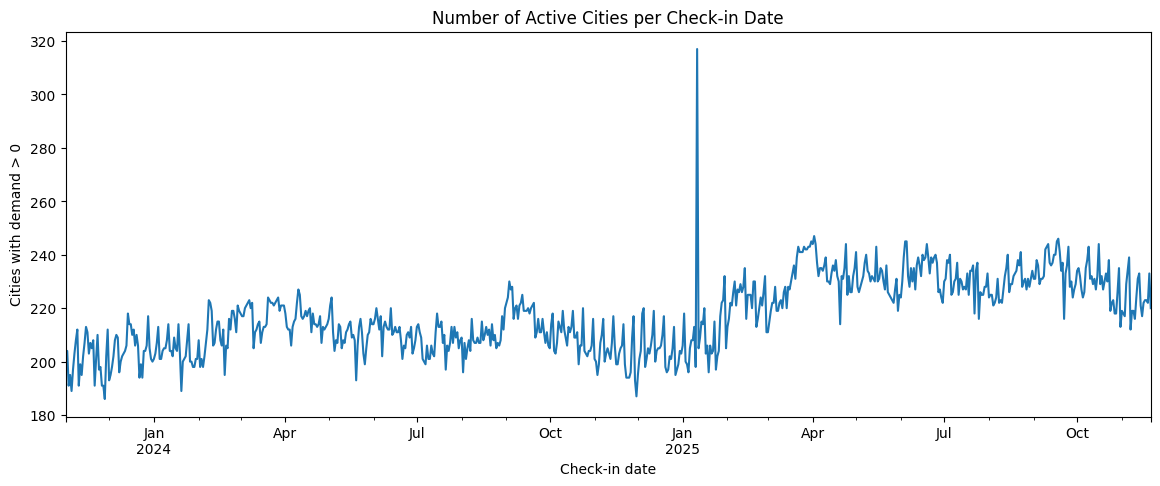

In [100]:
import matplotlib.pyplot as plt

checkin_daily["active_cities"].plot(
    figsize=(14, 5),
    title="Number of Active Cities per Check-in Date"
)

plt.xlabel("Check-in date")
plt.ylabel("Cities with demand > 0")
plt.show()

In [101]:
# ============================================================
# STRUCTURAL CHECK 4 — Evaluation absence
# ============================================================

inactive_eval = set(cities["city_code"]) - eval_codes

print("Cities absent from evaluation:",
      len(inactive_eval))

print(
    "Of those, one-checkin historical cities:",
    len(inactive_eval & one_codes)
)

print(
    "Percentage of evaluation-absent cities explained "
    "by one-checkin group:",
    len(inactive_eval & one_codes) / len(inactive_eval)
)

Cities absent from evaluation: 82
Of those, one-checkin historical cities: 61
Percentage of evaluation-absent cities explained by one-checkin group: 0.7439024390243902


In [102]:
same_day = search[
    search["lead_time"] == 0
].copy()

same_day_daily = (
    same_day.groupby("checkin")
    .agg(
        same_day_searches=("search_count", "sum"),
        active_cities=("city_code", "nunique"),
        rows=("search_count", "size")
    )
)

display(
    same_day_daily.loc["2025-01-01":"2025-01-20"]
)

,same_day_searches,active_cities,rows
checkin,,,
2025-01-01,23218,157,157
2025-01-02,48846,181,181
2025-01-03,21181,151,151
2025-01-04,17854,152,152
2025-01-05,17056,146,146
2025-01-06,18495,152,152
2025-01-07,18589,148,148
2025-01-08,22350,162,162
2025-01-09,43482,172,172


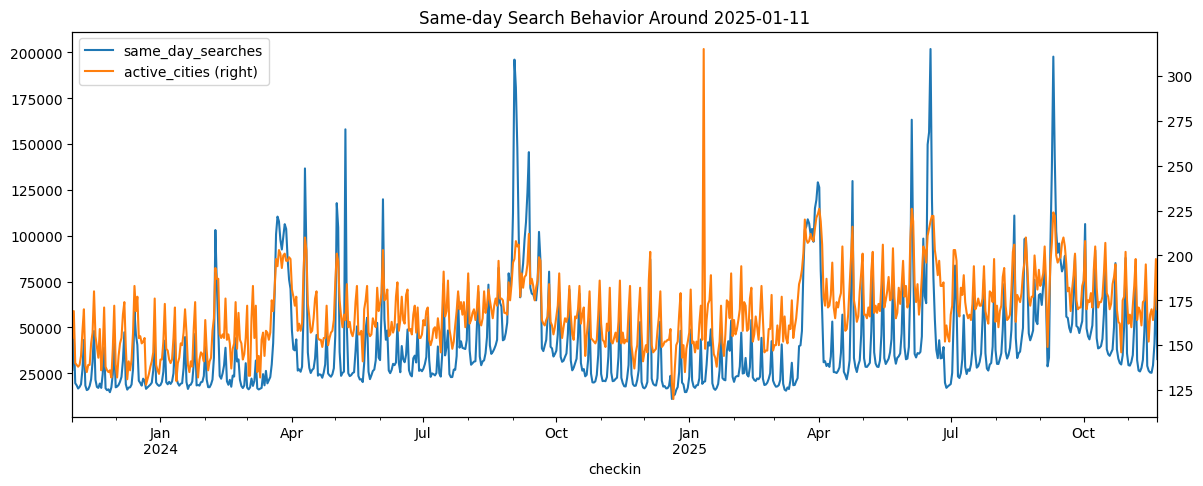

In [103]:
same_day_daily[
    ["same_day_searches", "active_cities"]
].plot(
    figsize=(14, 5),
    secondary_y="active_cities"
)

plt.title("Same-day Search Behavior Around 2025-01-11")
plt.show()

In [104]:
jan11_same_day = search[
    (search["log_date"] == "2025-01-11") &
    (search["checkin"] == "2025-01-11")
]

print(
    jan11_same_day["search_count"]
    .value_counts()
    .sort_index()
    .head(30)
)

search_count
2     152
3      12
4      20
5       8
6       5
7       7
8       7
9       6
10      3
11      3
12      3
14      4
15      2
16      3
17      4
18      1
19      2
21      2
22      2
23      1
25      4
27      1
28      3
29      1
30      1
31      1
34      1
35      1
36      1
37      1
Name: count, dtype: int64


In [105]:
def exact_two_stats(date):
    x = search[
        (search["log_date"] == date) &
        (search["checkin"] == date)
    ]

    return {
        "date": date,
        "cities": x["city_code"].nunique(),
        "rows": len(x),
        "exactly_2": (x["search_count"] == 2).sum(),
        "share_exactly_2": (x["search_count"] == 2).mean()
                         if len(x) else np.nan
    }

comparison = pd.DataFrame([
    exact_two_stats(pd.Timestamp("2025-01-04")),
    exact_two_stats(pd.Timestamp("2025-01-05")),
    exact_two_stats(pd.Timestamp("2025-01-10")),
    exact_two_stats(pd.Timestamp("2025-01-11")),
    exact_two_stats(pd.Timestamp("2025-01-12")),
    exact_two_stats(pd.Timestamp("2025-01-18")),
])

display(comparison)

,date,cities,rows,exactly_2,share_exactly_2
0,2025-01-04,152,152,19,0.125000
1,2025-01-05,146,146,12,0.082192
2,2025-01-10,153,153,12,0.078431
3,2025-01-11,315,315,152,0.482540
4,2025-01-12,148,148,11,0.074324
5,2025-01-18,145,145,14,0.096552


In [106]:
established_codes = set(
    city_coverage.loc[
        city_coverage["unique_checkins"] >= 500,
        "city_code"
    ]
)

established_same_day = same_day[
    same_day["city_code"].isin(established_codes)
]

established_daily = (
    established_same_day.groupby("checkin")
    ["search_count"]
    .sum()
)

display(
    established_daily.loc[
        "2025-01-01":"2025-01-20"
    ]
)

checkin
2025-01-01    23213
2025-01-02    48840
2025-01-03    21181
2025-01-04    17851
2025-01-05    17053
2025-01-06    18491
2025-01-07    18583
2025-01-08    22346
2025-01-09    43479
2025-01-10    19260
2025-01-11    20131
2025-01-12    20630
2025-01-13    29694
2025-01-14    41929
2025-01-15    40149
2025-01-16    49039
2025-01-17    19555
2025-01-18    16771
2025-01-19    15991
2025-01-20    17092
Name: search_count, dtype: int64

In [107]:
important_horizons = [59, 45, 30, 21, 14, 7, 3, 1, 0]

result = (
    lead_volume[
        lead_volume["lead_time"].isin(important_horizons)
    ][
        [
            "lead_time",
            "search_count",
            "share_of_total",
            "completion_rate"
        ]
    ]
    .sort_values("lead_time", ascending=False)
)

display(result)

NameError: name 'lead_volume' is not defined

In [ ]:
# اگر lead_time هنوز وجود ندارد، بسازش
if "lead_time" not in search.columns:
    search["lead_time"] = (
        search["checkin"] - search["log_date"]
    ).dt.days

# حجم Search در هر lead_time
lead_volume = (
    search
    .groupby("lead_time", as_index=False)["search_count"]
    .sum()
    .sort_values("lead_time", ascending=False)
)

# سهم هر lead_time از کل Demand
lead_volume["share_of_total"] = (
    lead_volume["search_count"]
    / lead_volume["search_count"].sum()
)

# Completion Rate:
# در D-30، Searchهای D-59 تا D-30 مشاهده شده‌اند
lead_volume["cumulative_observed"] = (
    lead_volume["search_count"].cumsum()
)

lead_volume["completion_rate"] = (
    lead_volume["cumulative_observed"]
    / lead_volume["search_count"].sum()
)

# Horizonهای مهم
important_horizons = [59, 45, 30, 21, 14, 7, 3, 1, 0]

result = (
    lead_volume[
        lead_volume["lead_time"].isin(important_horizons)
    ][
        [
            "lead_time",
            "search_count",
            "share_of_total",
            "completion_rate"
        ]
    ]
    .sort_values("lead_time", ascending=False)
)

display(result)

In [ ]:
# ============================================================
# Pair-normalized completion curves
# ============================================================

# demand per city × checkin × lead_time
pair_lead = (
    search.groupby(
        ["city_code", "checkin", "lead_time"],
        as_index=False
    )["search_count"]
    .sum()
)

# final demand of each city × checkin
pair_total = (
    pair_lead.groupby(
        ["city_code", "checkin"],
        as_index=False
    )["search_count"]
    .sum()
    .rename(columns={"search_count": "final_demand"})
)

pair_lead = pair_lead.merge(
    pair_total,
    on=["city_code", "checkin"],
    how="left"
)

# full grid only for positive-demand pairs
pairs = pair_total[["city_code", "checkin"]].copy()

lead_times = pd.DataFrame({
    "lead_time": np.arange(60)
})

pairs["_key"] = 1
lead_times["_key"] = 1

full_pair_lead = (
    pairs.merge(lead_times, on="_key")
    .drop(columns="_key")
)

full_pair_lead = full_pair_lead.merge(
    pair_lead[
        ["city_code", "checkin", "lead_time", "search_count", "final_demand"]
    ],
    on=["city_code", "checkin", "lead_time"],
    how="left"
)

full_pair_lead["search_count"] = (
    full_pair_lead["search_count"].fillna(0)
)

full_pair_lead = full_pair_lead.merge(
    pair_total,
    on=["city_code", "checkin"],
    how="left",
    suffixes=("", "_pair")
)

full_pair_lead["final_demand"] = (
    full_pair_lead["final_demand"]
    .fillna(full_pair_lead["final_demand_pair"])
)

# Sort from D-59 toward D-0
full_pair_lead = full_pair_lead.sort_values(
    ["city_code", "checkin", "lead_time"],
    ascending=[True, True, False]
)

full_pair_lead["cum_observed"] = (
    full_pair_lead.groupby(
        ["city_code", "checkin"]
    )["search_count"]
    .cumsum()
)

full_pair_lead["completion_rate"] = (
    full_pair_lead["cum_observed"]
    / full_pair_lead["final_demand"]
)

pair_completion_summary = (
    full_pair_lead[
        full_pair_lead["lead_time"].isin(
            [30, 21, 14, 7, 3, 1]
        )
    ]
    .groupby("lead_time")["completion_rate"]
    .agg(
        mean="mean",
        median="median",
        p25=lambda x: x.quantile(.25),
        p75=lambda x: x.quantile(.75),
        p90=lambda x: x.quantile(.90),
    )
    .sort_index(ascending=False)
)

display(pair_completion_summary)

In [ ]:
# ============================================================
# Completion behavior by final-demand tier
# NOTE: final_demand is used ONLY for analysis here,
# not as a future model feature.
# ============================================================

analysis_df = full_pair_lead.copy()

analysis_df["demand_tier"] = pd.cut(
    analysis_df["final_demand"],
    bins=[0, 5, 20, 100, 1000, np.inf],
    labels=[
        "1-5",
        "6-20",
        "21-100",
        "101-1000",
        "1000+"
    ],
    include_lowest=True
)

horizons = [30, 21, 14, 7, 3, 1]

tier_completion = (
    analysis_df[
        analysis_df["lead_time"].isin(horizons)
    ]
    .groupby(
        ["demand_tier", "lead_time"],
        observed=True
    )["completion_rate"]
    .median()
    .unstack("lead_time")
)

tier_completion = tier_completion[
    [30, 21, 14, 7, 3, 1]
]

display(tier_completion)

# Number of positive city×checkin pairs in each tier
pair_tiers = (
    pair_total.assign(
        demand_tier=pd.cut(
            pair_total["final_demand"],
            bins=[0, 5, 20, 100, 1000, np.inf],
            labels=[
                "1-5",
                "6-20",
                "21-100",
                "101-1000",
                "1000+"
            ],
            include_lowest=True
        )
    )
)

display(
    pair_tiers["demand_tier"]
    .value_counts()
    .sort_index()
)

In [ ]:
# ============================================================
# City-level completion fingerprints
# ============================================================

horizons = [30, 21, 14, 7, 3, 1]

city_completion = (
    full_pair_lead[
        full_pair_lead["lead_time"].isin(horizons)
    ]
    .groupby(["city_code", "lead_time"])
    .apply(
        lambda g: np.average(
            g["completion_rate"],
            weights=g["final_demand"]
        )
        if g["final_demand"].sum() > 0
        else np.nan
    )
    .rename("completion_rate")
    .reset_index()
)

city_fingerprint = (
    city_completion
    .pivot(
        index="city_code",
        columns="lead_time",
        values="completion_rate"
    )
    .rename(columns={
        30: "comp_d30",
        21: "comp_d21",
        14: "comp_d14",
        7: "comp_d7",
        3: "comp_d3",
        1: "comp_d1"
    })
    .reset_index()
)

# Historical support for reliability
city_fingerprint = city_fingerprint.merge(
    city_coverage[
        [
            "city_code",
            "unique_checkins",
            "total_searches"
        ]
    ],
    on="city_code",
    how="left"
)

# Reliable cities only for behavioral analysis
reliable = city_fingerprint[
    (city_fingerprint["unique_checkins"] >= 180) &
    (city_fingerprint["total_searches"] >= 1000)
].copy()

print("Reliable cities:", len(reliable))

display(
    reliable[
        [
            "comp_d30",
            "comp_d21",
            "comp_d14",
            "comp_d7",
            "comp_d3",
            "comp_d1"
        ]
    ].describe(
        percentiles=[.10, .25, .50, .75, .90]
    )
)

In [ ]:
display(
    reliable[
        [
            "city_code",
            "unique_checkins",
            "total_searches",
            "comp_d30",
            "comp_d14",
            "comp_d7",
            "comp_d3",
            "comp_d1"
        ]
    ]
    .sort_values("comp_d14")
    .head(15)
)

display(
    reliable[
        [
            "city_code",
            "unique_checkins",
            "total_searches",
            "comp_d30",
            "comp_d14",
            "comp_d7",
            "comp_d3",
            "comp_d1"
        ]
    ]
    .sort_values("comp_d14", ascending=False)
    .head(15)
)

In [ ]:
# ============================================================
# Temporal stability of city completion behavior
# ============================================================

horizons = [30, 21, 14, 7, 3, 1]

min_checkin = full_pair_lead["checkin"].min()
max_checkin = full_pair_lead["checkin"].max()

split_date = min_checkin + (max_checkin - min_checkin) / 2

print("Min checkin:", min_checkin)
print("Split date:", split_date)
print("Max checkin:", max_checkin)

temp = full_pair_lead[
    full_pair_lead["lead_time"].isin(horizons)
].copy()

temp["period"] = np.where(
    temp["checkin"] <= split_date,
    "first_half",
    "second_half"
)

# Weighted completion within each city × period × horizon
period_completion = (
    temp
    .groupby(
        ["city_code", "period", "lead_time"]
    )
    .apply(
        lambda g: np.average(
            g["completion_rate"],
            weights=g["final_demand"]
        )
        if g["final_demand"].sum() > 0
        else np.nan
    )
    .rename("completion_rate")
    .reset_index()
)

period_pivot = (
    period_completion
    .pivot_table(
        index=["city_code", "lead_time"],
        columns="period",
        values="completion_rate"
    )
    .reset_index()
)

period_pivot = period_pivot.dropna(
    subset=["first_half", "second_half"]
)

display(period_pivot.head())

In [ ]:
d14_stability = (
    period_pivot[
        period_pivot["lead_time"] == 14
    ]
    .copy()
)

d14_stability["abs_diff"] = (
    d14_stability["first_half"]
    - d14_stability["second_half"]
).abs()

print("Most stable D-14 cities:")
display(
    d14_stability
    .sort_values("abs_diff")
    .head(15)
)

print("\nLeast stable D-14 cities:")
display(
    d14_stability
    .sort_values("abs_diff", ascending=False)
    .head(15)
)

In [ ]:
# ============================================================
# Support / reliability inside EACH historical half
# ============================================================

pair_support = pair_total.copy()

pair_support["period"] = np.where(
    pair_support["checkin"] <= split_date,
    "first_half",
    "second_half"
)

support = (
    pair_support
    .groupby(["city_code", "period"])
    .agg(
        positive_checkins=("checkin", "nunique"),
        total_demand=("final_demand", "sum")
    )
    .reset_index()
)

support_wide = support.pivot(
    index="city_code",
    columns="period",
    values=["positive_checkins", "total_demand"]
)

support_wide.columns = [
    f"{metric}_{period}"
    for metric, period in support_wide.columns
]

support_wide = support_wide.reset_index()

display(support_wide.head())

In [ ]:
# Preliminary reliability requirement:
# enough support in BOTH halves

stable_candidates = support_wide[
    (support_wide["positive_checkins_first_half"] >= 90) &
    (support_wide["positive_checkins_second_half"] >= 90) &
    (support_wide["total_demand_first_half"] >= 500) &
    (support_wide["total_demand_second_half"] >= 500)
]["city_code"]

print("Cities reliable in BOTH halves:", len(stable_candidates))

In [ ]:
period_reliable = period_pivot[
    period_pivot["city_code"].isin(stable_candidates)
].copy()

stability_rows = []

for h in horizons:

    x = period_reliable[
        period_reliable["lead_time"] == h
    ].copy()

    abs_diff = (
        x["first_half"] - x["second_half"]
    ).abs()

    stability_rows.append({
        "lead_time": h,
        "cities": len(x),

        "pearson": x[
            ["first_half", "second_half"]
        ].corr(method="pearson").iloc[0, 1],

        "spearman": x[
            ["first_half", "second_half"]
        ].corr(method="spearman").iloc[0, 1],

        "median_abs_diff": abs_diff.median(),
        "p90_abs_diff": abs_diff.quantile(0.90)
    })

stability_summary_reliable = (
    pd.DataFrame(stability_rows)
    .sort_values("lead_time", ascending=False)
)

display(stability_summary_reliable)

In [ ]:
# ============================================================
# Calendar structure of FINAL demand
# ============================================================

calendar_demand = historical_targets.copy()

calendar_demand["weekday"] = calendar_demand["checkin"].dt.day_name()
calendar_demand["weekday_num"] = calendar_demand["checkin"].dt.dayofweek
calendar_demand["year"] = calendar_demand["checkin"].dt.year
calendar_demand["month"] = calendar_demand["checkin"].dt.month

# Platform total final demand per check-in date
daily_total = (
    calendar_demand
    .groupby("checkin", as_index=False)["final_demand"]
    .sum()
)

daily_total["weekday"] = daily_total["checkin"].dt.day_name()
daily_total["weekday_num"] = daily_total["checkin"].dt.dayofweek
daily_total["year"] = daily_total["checkin"].dt.year
daily_total["month"] = daily_total["checkin"].dt.month

# Weekday behavior
weekday_summary = (
    daily_total
    .groupby(["weekday_num", "weekday"])
    ["final_demand"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        count="count"
    )
    .reset_index()
    .sort_values("weekday_num")
)

display(weekday_summary)

# Month behavior
month_summary = (
    daily_total
    .groupby("month")["final_demand"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        count="count"
    )
)

display(month_summary)

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_total["checkin"],
    daily_total["final_demand"]
)

plt.title("Total Final Demand by Check-in Date")
plt.xlabel("Check-in date")
plt.ylabel("Final demand")
plt.grid(alpha=0.2)

plt.show()

In [ ]:
# ============================================================
# Year × Month demand structure
# ============================================================

year_month_summary = (
    daily_total
    .groupby(["year", "month"])["final_demand"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        count="count"
    )
    .reset_index()
)

display(year_month_summary)

In [ ]:
month_year_median = (
    year_month_summary
    .pivot(
        index="month",
        columns="year",
        values="median"
    )
)

display(month_year_median)

In [ ]:
top_demand_dates = (
    daily_total
    .sort_values(
        "final_demand",
        ascending=False
    )
    .head(20)
    .copy()
)

top_demand_dates["weekday"] = (
    top_demand_dates["checkin"]
    .dt.day_name()
)

display(top_demand_dates)

In [ ]:
pip install jdatetime


In [ ]:
import jdatetime

def to_jalali_parts(ts):
    j = jdatetime.date.fromgregorian(
        date=ts.date()
    )
    return pd.Series({
        "jalali_year": j.year,
        "jalali_month": j.month,
        "jalali_day": j.day
    })

jalali_parts = daily_total["checkin"].apply(
    to_jalali_parts
)

daily_jalali = pd.concat(
    [
        daily_total.reset_index(drop=True),
        jalali_parts.reset_index(drop=True)
    ],
    axis=1
)

display(daily_jalali.head())

In [ ]:
jalali_month_summary = (
    daily_jalali
    .groupby("jalali_month")["final_demand"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        count="count"
    )
)

display(jalali_month_summary)

In [ ]:
jalali_year_month = (
    daily_jalali
    .groupby(
        ["jalali_year", "jalali_month"]
    )["final_demand"]
    .agg(
        mean="mean",
        median="median",
        max="max",
        count="count"
    )
    .reset_index()
)

display(jalali_year_month)

In [ ]:
# ============================================================
# Focus on Azar: 1402 vs 1403
# ============================================================

azar = daily_jalali[
    daily_jalali["jalali_month"] == 9
].copy()

azar["weekday_num"] = azar["checkin"].dt.dayofweek
azar["weekday"] = azar["checkin"].dt.day_name()

azar_compare = (
    azar[
        azar["jalali_year"].isin([1402, 1403])
    ]
    .pivot_table(
        index="jalali_day",
        columns="jalali_year",
        values="final_demand"
    )
)

display(azar_compare)

In [ ]:
azar_valid = azar_compare.dropna()

pearson_azar = azar_valid.corr(
    method="pearson"
).iloc[0, 1]

spearman_azar = azar_valid.corr(
    method="spearman"
).iloc[0, 1]

print("Azar 1402 vs 1403 Pearson:", pearson_azar)
print("Azar 1402 vs 1403 Spearman:", spearman_azar)

In [ ]:
azar_weekday = (
    azar[
        azar["jalali_year"].isin([1402, 1403])
    ]
    .groupby(
        ["jalali_year", "weekday_num", "weekday"]
    )["final_demand"]
    .agg(
        mean="mean",
        median="median"
    )
    .reset_index()
    .sort_values(
        ["jalali_year", "weekday_num"]
    )
)

display(azar_weekday)

In [ ]:
# ============================================================
# Iran calendar / weekend features
# ============================================================

daily_jalali["weekday_num"] = daily_jalali["checkin"].dt.dayofweek
daily_jalali["weekday"] = daily_jalali["checkin"].dt.day_name()

# Iran weekend-related features
daily_jalali["is_thursday"] = (
    daily_jalali["weekday_num"] == 3
).astype(int)

daily_jalali["is_friday"] = (
    daily_jalali["weekday_num"] == 4
).astype(int)

daily_jalali["is_weekend_iran"] = (
    daily_jalali["weekday_num"].isin([3, 4])
).astype(int)

display(
    daily_jalali[
        [
            "checkin",
            "weekday",
            "is_thursday",
            "is_friday",
            "is_weekend_iran"
        ]
    ].head(10)
)

In [ ]:
# ============================================================
# Weekday-normalized demand
# ============================================================

weekday_baseline = (
    daily_jalali
    .groupby("weekday_num")["final_demand"]
    .median()
    .rename("weekday_baseline")
)

daily_normalized = daily_jalali.merge(
    weekday_baseline,
    left_on="weekday_num",
    right_index=True,
    how="left"
)

daily_normalized["weekday_uplift"] = (
    daily_normalized["final_demand"]
    / daily_normalized["weekday_baseline"]
)

display(
    daily_normalized[
        [
            "checkin",
            "jalali_year",
            "jalali_month",
            "jalali_day",
            "weekday",
            "final_demand",
            "weekday_baseline",
            "weekday_uplift"
        ]
    ].head()
)

In [ ]:
# ============================================================
# Largest demand anomalies after removing weekday effect
# ============================================================

top_uplift_dates = (
    daily_normalized
    .sort_values(
        "weekday_uplift",
        ascending=False
    )
    .head(30)
)

display(
    top_uplift_dates[
        [
            "checkin",
            "jalali_year",
            "jalali_month",
            "jalali_day",
            "weekday",
            "final_demand",
            "weekday_baseline",
            "weekday_uplift"
        ]
    ]
)

In [ ]:
pip install holidays

In [ ]:
import holidays
import pandas as pd
import numpy as np

# Historical years + target year
ir_holidays = holidays.country_holidays(
    "IR",
    years=[2023, 2024, 2025],
    language="fa_IR"
)

holiday_df = pd.DataFrame(
    [
        {
            "checkin": pd.Timestamp(date),
            "holiday_name": name
        }
        for date, name in ir_holidays.items()
    ]
).sort_values("checkin")

holiday_df["is_official_holiday"] = 1

display(holiday_df)

In [ ]:
calendar_features = daily_jalali.merge(
    holiday_df,
    on="checkin",
    how="left"
)

calendar_features["is_official_holiday"] = (
    calendar_features["is_official_holiday"]
    .fillna(0)
    .astype(int)
)

calendar_features["holiday_name"] = (
    calendar_features["holiday_name"]
    .fillna("None")
)

# Iran weekend definition for this project
calendar_features["is_thursday"] = (
    calendar_features["weekday_num"] == 3
).astype(int)

calendar_features["is_friday"] = (
    calendar_features["weekday_num"] == 4
).astype(int)

calendar_features["is_weekend_iran"] = (
    calendar_features["weekday_num"].isin([3, 4])
).astype(int)

display(
    calendar_features[
        [
            "checkin",
            "jalali_year",
            "jalali_month",
            "jalali_day",
            "weekday",
            "is_official_holiday",
            "holiday_name"
        ]
    ].head(20)
)

In [ ]:
calendar_features = calendar_features.sort_values(
    "checkin"
).reset_index(drop=True)

# Day considered non-working/travel-friendly
calendar_features["is_nonworking"] = (
    (
        calendar_features["is_official_holiday"] == 1
    )
    |
    (
        calendar_features["is_weekend_iran"] == 1
    )
).astype(int)

# Is today sandwiched between two non-working days?
calendar_features["is_bridge_day"] = (
    (calendar_features["is_nonworking"].shift(1) == 1)
    &
    (calendar_features["is_nonworking"].shift(-1) == 1)
    &
    (calendar_features["is_nonworking"] == 0)
).astype(int)

In [ ]:
check = daily_normalized.merge(
    calendar_features[
        [
            "checkin",
            "is_official_holiday",
            "holiday_name",
            "is_weekend_iran",
            "is_bridge_day"
        ]
    ],
    on="checkin",
    how="left"
)

display(
    check.sort_values(
        "weekday_uplift",
        ascending=False
    )[
        [
            "checkin",
            "jalali_year",
            "jalali_month",
            "jalali_day",
            "weekday",
            "final_demand",
            "weekday_uplift",
            "is_official_holiday",
            "holiday_name",
            "is_bridge_day"
        ]
    ].head(30)
)

In [ ]:
# ============================================================
# MASTER CALENDAR — historical + target period
# ============================================================

import pandas as pd
import numpy as np
import jdatetime
import holidays

CAL_START = search["checkin"].min()

if "evaluation" in globals():
    CAL_END = evaluation["checkin"].max()
else:
    CAL_END = pd.Timestamp("2025-12-21")

calendar_master = pd.DataFrame({
    "checkin": pd.date_range(
        CAL_START,
        CAL_END,
        freq="D"
    )
})

calendar_master["weekday_num"] = (
    calendar_master["checkin"].dt.dayofweek
)

calendar_master["weekday"] = (
    calendar_master["checkin"].dt.day_name()
)

# Iran weekend convention for THIS project
calendar_master["is_thursday"] = (
    calendar_master["weekday_num"] == 3
).astype(int)

calendar_master["is_friday"] = (
    calendar_master["weekday_num"] == 4
).astype(int)

calendar_master["is_weekend_iran"] = (
    calendar_master["weekday_num"].isin([3, 4])
).astype(int)


# Jalali parts
def jalali_parts(ts):
    j = jdatetime.date.fromgregorian(
        date=ts.date()
    )
    return pd.Series({
        "jalali_year": j.year,
        "jalali_month": j.month,
        "jalali_day": j.day
    })


jp = calendar_master["checkin"].apply(
    jalali_parts
)

calendar_master = pd.concat(
    [
        calendar_master,
        jp
    ],
    axis=1
)

display(calendar_master.head())
display(calendar_master.tail())

In [ ]:
# ============================================================
# OFFICIAL IRAN HOLIDAYS
# ============================================================

years = sorted(
    calendar_master["checkin"]
    .dt.year
    .unique()
)

ir_holidays = holidays.country_holidays(
    "IR",
    years=years,
    language="fa_IR"
)

holiday_df = pd.DataFrame(
    [
        {
            "checkin": pd.Timestamp(d),
            "holiday_name": name
        }
        for d, name in ir_holidays.items()
    ]
)

holiday_df["is_official_holiday"] = 1

calendar_master = calendar_master.merge(
    holiday_df,
    on="checkin",
    how="left"
)

calendar_master["is_official_holiday"] = (
    calendar_master["is_official_holiday"]
    .fillna(0)
    .astype(int)
)

calendar_master["holiday_name"] = (
    calendar_master["holiday_name"]
    .fillna("None")
)

In [ ]:
# ============================================================
# HOLIDAY TYPE
# ============================================================

solar_fixed_dates = {
    (1, 1),
    (1, 2),
    (1, 3),
    (1, 4),
    (1, 12),
    (1, 13),
    (3, 14),
    (3, 15),
    (11, 22),
    (12, 29),
}

calendar_master["is_solar_fixed_holiday"] = (
    calendar_master.apply(
        lambda r:
        int(
            r["is_official_holiday"] == 1
            and
            (
                r["jalali_month"],
                r["jalali_day"]
            )
            in solar_fixed_dates
        ),
        axis=1
    )
)

In [ ]:
religious_keywords = [
    "شهادت",
    "میلاد",
    "ولادت",
    "عید سعید فطر",
    "عید فطر",
    "عید قربان",
    "غدیر",
    "عاشورا",
    "تاسوعا",
    "اربعین",
    "مبعث",
    "وفات",
    "رحلت رسول",
    "نیمه شعبان",
]

pattern = "|".join(
    religious_keywords
)

calendar_master["is_lunar_religious_holiday"] = (
    (
        calendar_master["is_official_holiday"] == 1
    )
    &
    (
        calendar_master["holiday_name"]
        .str.contains(
            pattern,
            regex=True,
            na=False
        )
    )
).astype(int)

In [ ]:
calendar_master["is_nonworking"] = (
    (
        calendar_master["is_weekend_iran"] == 1
    )
    |
    (
        calendar_master["is_official_holiday"] == 1
    )
).astype(int)

In [ ]:
calendar_master["is_nonworking"] = (
    (
        calendar_master["is_weekend_iran"] == 1
    )
    |
    (
        calendar_master["is_official_holiday"] == 1
    )
).astype(int)

In [ ]:
calendar_master["is_bridge_day"] = (
    (
        calendar_master["is_nonworking"]
        .shift(1) == 1
    )
    &
    (
        calendar_master["is_nonworking"]
        .shift(-1) == 1
    )
    &
    (
        calendar_master["is_nonworking"] == 0
    )
).astype(int)

In [ ]:
# ============================================================
# NON-WORKING BLOCK LENGTH
# ============================================================

groups = (
    calendar_master["is_nonworking"]
    !=
    calendar_master["is_nonworking"].shift()
).cumsum()

block_size = (
    calendar_master
    .groupby(groups)["is_nonworking"]
    .transform("size")
)

calendar_master["nonworking_block_length"] = np.where(
    calendar_master["is_nonworking"] == 1,
    block_size,
    0
)

In [ ]:
calendar_master["is_travel_block_day"] = (
    (
        calendar_master["is_nonworking"] == 1
    )
    |
    (
        calendar_master["is_bridge_day"] == 1
    )
).astype(int)

travel_groups = (
    calendar_master["is_travel_block_day"]
    !=
    calendar_master[
        "is_travel_block_day"
    ].shift()
).cumsum()

travel_block_size = (
    calendar_master
    .groupby(travel_groups)[
        "is_travel_block_day"
    ]
    .transform("size")
)

calendar_master["travel_block_length"] = np.where(
    calendar_master["is_travel_block_day"] == 1,
    travel_block_size,
    0
)

In [ ]:
calendar_master["is_nowruz_travel_window"] = (
    (
        calendar_master["jalali_month"] == 1
    )
    &
    (
        calendar_master["jalali_day"]
        .between(1, 13)
    )
).astype(int)

In [ ]:
calendar_analysis = (
    daily_normalized.merge(
        calendar_master[
            [
                "checkin",
                "is_official_holiday",
                "is_solar_fixed_holiday",
                "is_lunar_religious_holiday",
                "is_weekend_iran",
                "is_bridge_day",
                "nonworking_block_length",
                "travel_block_length",
                "days_to_next_holiday",
                "days_since_prev_holiday",
                "is_nowruz_travel_window",
                "holiday_name"
            ]
        ],
        on="checkin",
        how="left"
    )
)

In [ ]:
holiday_effect_summary = (
    calendar_analysis
    .groupby(
        "is_official_holiday"
    )["weekday_uplift"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        p75=lambda x: x.quantile(.75),
        p90=lambda x: x.quantile(.90)
    )
)

display(holiday_effect_summary)

In [ ]:
bridge_effect_summary = (
    calendar_analysis
    .groupby(
        "is_bridge_day"
    )["weekday_uplift"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        p75=lambda x: x.quantile(.75),
        p90=lambda x: x.quantile(.90)
    )
)

display(bridge_effect_summary)

In [ ]:
block_effect_summary = (
    calendar_analysis[
        calendar_analysis[
            "travel_block_length"
        ] > 0
    ]
    .groupby(
        "travel_block_length"
    )["weekday_uplift"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        max="max"
    )
)

display(block_effect_summary)

In [ ]:
azar_1404_calendar = (
    calendar_master[
        (calendar_master["jalali_year"] == 1404)
        &
        (calendar_master["jalali_month"] == 9)
    ][
        [
            "checkin",
            "jalali_day",
            "weekday",
            "is_official_holiday",
            "holiday_name",
            "is_weekend_iran",
            "is_bridge_day",
            "travel_block_length",
            "days_to_next_holiday",
            "days_since_prev_holiday"
        ]
    ]
)

display(azar_1404_calendar)

In [ ]:
# ============================================================
# REBUILD CALENDAR / HOLIDAY FEATURES — CLEAN VERSION
# ============================================================

import pandas as pd
import numpy as np
import holidays


# ------------------------------------------------------------
# 1. Make sure calendar_master is sorted
# ------------------------------------------------------------

calendar_master = (
    calendar_master
    .sort_values("checkin")
    .reset_index(drop=True)
    .copy()
)


# ------------------------------------------------------------
# 2. Remove old holiday-derived columns if they already exist
# ------------------------------------------------------------

cols_to_remove = [
    "holiday_name",
    "is_official_holiday",
    "is_solar_fixed_holiday",
    "is_lunar_religious_holiday",
    "next_holiday_date",
    "prev_holiday_date",
    "days_to_next_holiday",
    "days_since_prev_holiday",
    "is_nonworking",
    "is_bridge_day",
    "nonworking_block_length",
    "is_travel_block_day",
    "travel_block_length",
    "is_nowruz_travel_window",
]

calendar_master = calendar_master.drop(
    columns=cols_to_remove,
    errors="ignore"
)


# ------------------------------------------------------------
# 3. Weekday / Iran weekend features
# ------------------------------------------------------------

calendar_master["weekday_num"] = (
    calendar_master["checkin"].dt.dayofweek
)

calendar_master["weekday"] = (
    calendar_master["checkin"].dt.day_name()
)

calendar_master["is_thursday"] = (
    calendar_master["weekday_num"] == 3
).astype(int)

calendar_master["is_friday"] = (
    calendar_master["weekday_num"] == 4
).astype(int)

calendar_master["is_weekend_iran"] = (
    calendar_master["weekday_num"].isin([3, 4])
).astype(int)


# ------------------------------------------------------------
# 4. Load Iran holidays with buffer years
#
# Important:
# We include one year BEFORE and one year AFTER our calendar.
# This makes prev/next holiday distance available near boundaries.
# ------------------------------------------------------------

min_year = calendar_master["checkin"].dt.year.min()
max_year = calendar_master["checkin"].dt.year.max()

holiday_years = list(
    range(
        min_year - 1,
        max_year + 2
    )
)

print("Holiday years loaded:", holiday_years)

ir_holidays = holidays.country_holidays(
    "IR",
    years=holiday_years,
    language="fa_IR"
)


# ------------------------------------------------------------
# 5. Build holiday table
# ------------------------------------------------------------

holiday_df = pd.DataFrame(
    [
        {
            "holiday_date": pd.Timestamp(date),
            "holiday_name": name
        }
        for date, name in ir_holidays.items()
    ]
)

holiday_df = (
    holiday_df
    .sort_values("holiday_date")
    .drop_duplicates("holiday_date")
    .reset_index(drop=True)
)

holiday_df["is_official_holiday"] = 1


# ------------------------------------------------------------
# 6. Merge holiday information onto calendar
# ------------------------------------------------------------

calendar_master = calendar_master.merge(
    holiday_df.rename(
        columns={
            "holiday_date": "checkin"
        }
    ),
    on="checkin",
    how="left"
)

calendar_master["is_official_holiday"] = (
    calendar_master["is_official_holiday"]
    .fillna(0)
    .astype(int)
)

calendar_master["holiday_name"] = (
    calendar_master["holiday_name"]
    .fillna("None")
)


# ------------------------------------------------------------
# 7. Solar-fixed holiday flag
# ------------------------------------------------------------

solar_fixed_dates = {
    (1, 1),
    (1, 2),
    (1, 3),
    (1, 4),
    (1, 12),
    (1, 13),
    (3, 14),
    (3, 15),
    (11, 22),
    (12, 29),
}

calendar_master["is_solar_fixed_holiday"] = (
    calendar_master.apply(
        lambda r: int(
            r["is_official_holiday"] == 1
            and
            (
                r["jalali_month"],
                r["jalali_day"]
            ) in solar_fixed_dates
        ),
        axis=1
    )
)


# ------------------------------------------------------------
# 8. Lunar / religious holiday flag
#
# These are NOT tied to a fixed Jalali day.
# We identify them using the actual holiday name
# returned for that specific year.
# ------------------------------------------------------------

religious_keywords = [
    "شهادت",
    "میلاد",
    "ولادت",
    "عید سعید فطر",
    "عید فطر",
    "عید قربان",
    "غدیر",
    "عاشورا",
    "تاسوعا",
    "اربعین",
    "مبعث",
    "وفات",
    "رحلت رسول",
    "نیمه شعبان",
]

religious_pattern = "|".join(
    religious_keywords
)

calendar_master["is_lunar_religious_holiday"] = (
    (
        calendar_master["is_official_holiday"] == 1
    )
    &
    (
        calendar_master["holiday_name"]
        .str.contains(
            religious_pattern,
            regex=True,
            na=False
        )
    )
).astype(int)


# ------------------------------------------------------------
# 9. Previous / next official holiday distance
# ------------------------------------------------------------

holiday_dates = (
    holiday_df[
        ["holiday_date"]
    ]
    .drop_duplicates()
    .sort_values("holiday_date")
)


# NEXT holiday
calendar_master = pd.merge_asof(
    calendar_master.sort_values("checkin"),
    holiday_dates,
    left_on="checkin",
    right_on="holiday_date",
    direction="forward",
    allow_exact_matches=True
)

calendar_master = calendar_master.rename(
    columns={
        "holiday_date": "next_holiday_date"
    }
)


# PREVIOUS holiday
calendar_master = pd.merge_asof(
    calendar_master.sort_values("checkin"),
    holiday_dates,
    left_on="checkin",
    right_on="holiday_date",
    direction="backward",
    allow_exact_matches=True
)

calendar_master = calendar_master.rename(
    columns={
        "holiday_date": "prev_holiday_date"
    }
)


calendar_master["days_to_next_holiday"] = (
    calendar_master["next_holiday_date"]
    -
    calendar_master["checkin"]
).dt.days

calendar_master["days_since_prev_holiday"] = (
    calendar_master["checkin"]
    -
    calendar_master["prev_holiday_date"]
).dt.days


# ------------------------------------------------------------
# 10. Non-working days
#
# For this project:
# Thursday + Friday + official holiday
# ------------------------------------------------------------

calendar_master["is_nonworking"] = (
    (
        calendar_master["is_weekend_iran"] == 1
    )
    |
    (
        calendar_master["is_official_holiday"] == 1
    )
).astype(int)


# ------------------------------------------------------------
# 11. Bridge day
#
# Working day between two non-working days
# ------------------------------------------------------------

calendar_master["is_bridge_day"] = (
    (
        calendar_master["is_nonworking"].shift(1) == 1
    )
    &
    (
        calendar_master["is_nonworking"].shift(-1) == 1
    )
    &
    (
        calendar_master["is_nonworking"] == 0
    )
).astype(int)


# ------------------------------------------------------------
# 12. Consecutive non-working block length
# ------------------------------------------------------------

nonworking_groups = (
    calendar_master["is_nonworking"]
    !=
    calendar_master["is_nonworking"].shift()
).cumsum()

nonworking_sizes = (
    calendar_master
    .groupby(nonworking_groups)["is_nonworking"]
    .transform("size")
)

calendar_master["nonworking_block_length"] = np.where(
    calendar_master["is_nonworking"] == 1,
    nonworking_sizes,
    0
)


# ------------------------------------------------------------
# 13. Travel block:
# non-working days + bridge days
# ------------------------------------------------------------

calendar_master["is_travel_block_day"] = (
    (
        calendar_master["is_nonworking"] == 1
    )
    |
    (
        calendar_master["is_bridge_day"] == 1
    )
).astype(int)

travel_groups = (
    calendar_master["is_travel_block_day"]
    !=
    calendar_master["is_travel_block_day"].shift()
).cumsum()

travel_sizes = (
    calendar_master
    .groupby(travel_groups)["is_travel_block_day"]
    .transform("size")
)

calendar_master["travel_block_length"] = np.where(
    calendar_master["is_travel_block_day"] == 1,
    travel_sizes,
    0
)


# ------------------------------------------------------------
# 14. Nowruz travel window
# ------------------------------------------------------------

calendar_master["is_nowruz_travel_window"] = (
    (
        calendar_master["jalali_month"] == 1
    )
    &
    (
        calendar_master["jalali_day"]
        .between(1, 13)
    )
).astype(int)


# ------------------------------------------------------------
# 15. Sanity checks
# ------------------------------------------------------------

print("\nNaN check:")

print(
    "days_to_next_holiday NaN:",
    calendar_master[
        "days_to_next_holiday"
    ].isna().sum()
)

print(
    "days_since_prev_holiday NaN:",
    calendar_master[
        "days_since_prev_holiday"
    ].isna().sum()
)


# ------------------------------------------------------------
# 16. Show TARGET MONTH — Azar 1404
# ------------------------------------------------------------

azar_1404_calendar = (
    calendar_master[
        (calendar_master["jalali_year"] == 1404)
        &
        (calendar_master["jalali_month"] == 9)
    ][
        [
            "checkin",
            "jalali_day",
            "weekday",

            "is_official_holiday",
            "holiday_name",

            "is_solar_fixed_holiday",
            "is_lunar_religious_holiday",

            "is_thursday",
            "is_friday",
            "is_weekend_iran",

            "is_bridge_day",
            "travel_block_length",

            "days_to_next_holiday",
            "days_since_prev_holiday"
        ]
    ]
    .reset_index(drop=True)
)

display(azar_1404_calendar)

In [ ]:
# ============================================================
# HOLIDAY PROXIMITY EFFECT — BEFORE / AFTER
# ============================================================

calendar_analysis = (
    daily_normalized.merge(
        calendar_master[
            [
                "checkin",
                "is_official_holiday",
                "is_solar_fixed_holiday",
                "is_lunar_religious_holiday",
                "days_to_next_holiday",
                "days_since_prev_holiday",
                "holiday_name",
                "is_nowruz_travel_window",
            ]
        ],
        on="checkin",
        how="left"
    )
)

# ------------------------------------------------------------
# 1. Days BEFORE next official holiday
#    Exclude the holiday itself because we want pre-holiday effect
# ------------------------------------------------------------

calendar_analysis["before_holiday_bucket"] = pd.cut(
    calendar_analysis["days_to_next_holiday"],
    bins=[-0.1, 0.5, 1.5, 2.5, 3.5, 7.5, np.inf],
    labels=[
        "holiday_day",
        "1_day_before",
        "2_days_before",
        "3_days_before",
        "4_7_days_before",
        "8+_days_before"
    ]
)

before_summary = (
    calendar_analysis
    .groupby(
        "before_holiday_bucket",
        observed=True
    )["weekday_uplift"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        p75=lambda x: x.quantile(.75),
        p90=lambda x: x.quantile(.90)
    )
)

print("=== BEFORE / ON HOLIDAY ===")
display(before_summary)


# ------------------------------------------------------------
# 2. Days AFTER previous official holiday
# ------------------------------------------------------------

calendar_analysis["after_holiday_bucket"] = pd.cut(
    calendar_analysis["days_since_prev_holiday"],
    bins=[-0.1, 0.5, 1.5, 2.5, 3.5, 7.5, np.inf],
    labels=[
        "holiday_day",
        "1_day_after",
        "2_days_after",
        "3_days_after",
        "4_7_days_after",
        "8+_days_after"
    ]
)

after_summary = (
    calendar_analysis
    .groupby(
        "after_holiday_bucket",
        observed=True
    )["weekday_uplift"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        p75=lambda x: x.quantile(.75),
        p90=lambda x: x.quantile(.90)
    )
)

print("\n=== AFTER / ON HOLIDAY ===")
display(after_summary)


# ------------------------------------------------------------
# 3. Compare holiday TYPES
# ------------------------------------------------------------

holiday_type_rows = calendar_analysis[
    calendar_analysis["is_official_holiday"] == 1
].copy()

holiday_type_rows["holiday_type"] = np.select(
    [
        holiday_type_rows["is_solar_fixed_holiday"] == 1,
        holiday_type_rows["is_lunar_religious_holiday"] == 1,
    ],
    [
        "solar_fixed",
        "lunar_religious",
    ],
    default="other_official"
)

holiday_type_summary = (
    holiday_type_rows
    .groupby("holiday_type")["weekday_uplift"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        p75=lambda x: x.quantile(.75),
        p90=lambda x: x.quantile(.90)
    )
    .sort_values("median", ascending=False)
)

print("\n=== HOLIDAY TYPE ===")
display(holiday_type_summary)

In [ ]:
# ============================================================
# DECONFOUND SOLAR HOLIDAYS FROM NOWRUZ
# ============================================================

holiday_detail = calendar_analysis[
    calendar_analysis["is_official_holiday"] == 1
].copy()

holiday_detail["holiday_group"] = np.select(
    [
        holiday_detail["is_nowruz_travel_window"] == 1,

        (
            (holiday_detail["is_solar_fixed_holiday"] == 1)
            &
            (holiday_detail["is_nowruz_travel_window"] == 0)
        ),

        holiday_detail["is_lunar_religious_holiday"] == 1,
    ],
    [
        "nowruz",
        "other_solar_fixed",
        "lunar_religious",
    ],
    default="other_official"
)

holiday_group_summary = (
    holiday_detail
    .groupby("holiday_group")["weekday_uplift"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        p75=lambda x: x.quantile(.75),
        p90=lambda x: x.quantile(.90)
    )
    .sort_values("median", ascending=False)
)

display(holiday_group_summary)

In [ ]:
# ============================================================
# RECENT PLATFORM DEMAND LEVEL
# 28-day trailing window
# ============================================================

trend_df = (
    daily_jalali[
        [
            "checkin",
            "final_demand",
            "jalali_year",
            "jalali_month",
            "jalali_day",
            "weekday_num",
            "weekday"
        ]
    ]
    .sort_values("checkin")
    .reset_index(drop=True)
    .copy()
)

# Shift(1) = only information from PRIOR check-in dates
# This makes the feature usable later in backtesting too.
trend_df["recent_mean_28"] = (
    trend_df["final_demand"]
    .shift(1)
    .rolling(
        window=28,
        min_periods=14
    )
    .mean()
)

trend_df["recent_median_28"] = (
    trend_df["final_demand"]
    .shift(1)
    .rolling(
        window=28,
        min_periods=14
    )
    .median()
)

display(
    trend_df.tail(40)
)

In [ ]:
# ============================================================
# LEVEL ENTERING AZAR
# Last known day before Azar 1
# ============================================================

pre_azar = (
    trend_df[
        (trend_df["jalali_month"] == 8)
    ]
    .sort_values("checkin")
    .groupby("jalali_year")
    .tail(1)
    [
        [
            "checkin",
            "jalali_year",
            "jalali_month",
            "jalali_day",
            "final_demand",
            "recent_mean_28",
            "recent_median_28"
        ]
    ]
)

display(pre_azar)

In [ ]:
# ============================================================
# LEVEL RATIOS
# ============================================================

pre_azar = pre_azar.copy()

base_1403 = pre_azar.loc[
    pre_azar["jalali_year"] == 1403,
    "recent_median_28"
].iloc[0]

pre_azar["level_vs_1403"] = (
    pre_azar["recent_median_28"]
    / base_1403
)

display(pre_azar)

In [109]:
# ============================================================
# RECOVERY CELL — rebuild daily_jalali after kernel restart
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import jdatetime

# ------------------------------------------------------------
# 1. Find project root
# ------------------------------------------------------------

cwd = Path.cwd()

if (cwd / "data" / "raw").exists():
    ROOT = cwd
elif (cwd.parent / "data" / "raw").exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError("Project root not found.")

SEARCH_PATH = ROOT / "data" / "raw" / "search_data.csv"
CITIES_PATH = ROOT / "data" / "raw" / "cities.csv"

print("Project root:", ROOT)

# ------------------------------------------------------------
# 2. Load raw data
# ------------------------------------------------------------

search = pd.read_csv(
    SEARCH_PATH,
    parse_dates=["log_date", "checkin"],
    low_memory=False
)

cities = pd.read_csv(CITIES_PATH)

print("Search shape:", search.shape)
print("Cities shape:", cities.shape)

# ------------------------------------------------------------
# 3. Build FINAL demand per city × checkin
# ------------------------------------------------------------

final_demand_observed = (
    search
    .groupby(["city_code", "checkin"], as_index=False)["search_count"]
    .sum()
    .rename(columns={"search_count": "final_demand"})
)

# Full grid including zero-demand city/checkin pairs
city_codes = np.sort(cities["city_code"].unique())

checkin_dates = pd.date_range(
    search["checkin"].min(),
    search["checkin"].max(),
    freq="D"
)

full_target_grid = (
    pd.MultiIndex
    .from_product(
        [city_codes, checkin_dates],
        names=["city_code", "checkin"]
    )
    .to_frame(index=False)
)

historical_targets = full_target_grid.merge(
    final_demand_observed,
    on=["city_code", "checkin"],
    how="left"
)

historical_targets["final_demand"] = (
    historical_targets["final_demand"]
    .fillna(0)
    .astype("int64")
)

# ------------------------------------------------------------
# 4. Platform total demand per checkin date
# ------------------------------------------------------------

daily_total = (
    historical_targets
    .groupby("checkin", as_index=False)["final_demand"]
    .sum()
)

daily_total["weekday_num"] = (
    daily_total["checkin"].dt.dayofweek
)

daily_total["weekday"] = (
    daily_total["checkin"].dt.day_name()
)

daily_total["year"] = (
    daily_total["checkin"].dt.year
)

daily_total["month"] = (
    daily_total["checkin"].dt.month
)

# ------------------------------------------------------------
# 5. Add Jalali calendar
# ------------------------------------------------------------

def to_jalali_parts(ts):
    j = jdatetime.date.fromgregorian(
        date=ts.date()
    )

    return pd.Series({
        "jalali_year": j.year,
        "jalali_month": j.month,
        "jalali_day": j.day
    })

jalali_parts = (
    daily_total["checkin"]
    .apply(to_jalali_parts)
)

daily_jalali = pd.concat(
    [
        daily_total.reset_index(drop=True),
        jalali_parts.reset_index(drop=True)
    ],
    axis=1
)

print("\nRecovery complete.")
print("daily_jalali shape:", daily_jalali.shape)

display(daily_jalali.tail())

Project root: c:\Users\ASUS\pol4-hackathon
Search shape: (3298564, 4)
Cities shape: (321, 4)

Recovery complete.
daily_jalali shape: (752, 9)


,checkin,final_demand,weekday_num,weekday,year,month,jalali_year,jalali_month,jalali_day
747,2025-11-17,215054,0,Monday,2025,11,1404,8,26
748,2025-11-18,248213,1,Tuesday,2025,11,1404,8,27
749,2025-11-19,354309,2,Wednesday,2025,11,1404,8,28
750,2025-11-20,552780,3,Thursday,2025,11,1404,8,29
751,2025-11-21,310107,4,Friday,2025,11,1404,8,30


In [112]:
# ============================================================
# MULTI-WINDOW RECENT LEVEL CHECK
# ============================================================

trend_multi = (
    daily_jalali[
        [
            "checkin",
            "final_demand",
            "jalali_year",
            "jalali_month",
            "jalali_day"
        ]
    ]
    .sort_values("checkin")
    .reset_index(drop=True)
    .copy()
)

windows = [14, 28, 56, 84]

for w in windows:

    trend_multi[f"mean_{w}"] = (
        trend_multi["final_demand"]
        .shift(1)
        .rolling(
            window=w,
            min_periods=max(7, w // 2)
        )
        .mean()
    )

    trend_multi[f"median_{w}"] = (
        trend_multi["final_demand"]
        .shift(1)
        .rolling(
            window=w,
            min_periods=max(7, w // 2)
        )
        .median()
    )


# Last day of Aban for each year
pre_azar_multi = (
    trend_multi[
        trend_multi["jalali_month"] == 8
    ]
    .sort_values("checkin")
    .groupby("jalali_year")
    .tail(1)
    .copy()
)

display(
    pre_azar_multi[
        [
            "checkin",
            "jalali_year",
            "final_demand",

            "mean_14",
            "median_14",

            "mean_28",
            "median_28",

            "mean_56",
            "median_56",

            "mean_84",
            "median_84"
        ]
    ]
)

,checkin,jalali_year,final_demand,mean_14,median_14,mean_28,median_28,mean_56,median_56,mean_84,median_84
20,2023-11-21,1402,134543,209594.000000,175686.0,206967.600000,169440.5,NaN,NaN,NaN,NaN
385,2024-11-20,1403,221846,235375.928571,195256.5,235864.107143,197843.5,274452.035714,250328.5,448774.166667,304163.5
751,2025-11-21,1404,310107,299190.714286,249415.5,313875.178571,264124.5,356426.785714,317603.0,454832.285714,402925.0


In [111]:
# ============================================================
# 1404 vs 1403 LEVEL RATIOS BY WINDOW
# ============================================================

row_1403 = (
    pre_azar_multi[
        pre_azar_multi["jalali_year"] == 1403
    ]
    .iloc[0]
)

row_1404 = (
    pre_azar_multi[
        pre_azar_multi["jalali_year"] == 1404
    ]
    .iloc[0]
)

ratio_rows = []

for w in windows:

    ratio_rows.append({
        "window": w,

        "mean_ratio_1404_vs_1403":
            row_1404[f"mean_{w}"]
            / row_1403[f"mean_{w}"],

        "median_ratio_1404_vs_1403":
            row_1404[f"median_{w}"]
            / row_1403[f"median_{w}"]
    })

level_ratio_summary = pd.DataFrame(
    ratio_rows
)

display(level_ratio_summary)

,window,mean_ratio_1404_vs_1403,median_ratio_1404_vs_1403
0,14,1.271119,1.277374
1,28,1.330746,1.335017
2,56,1.298685,1.268745
3,84,1.013499,1.324699


In [113]:
# ============================================================
# BUILD EVALUATION SNAPSHOT
# as of 2025-11-21 = 30 Aban 1404
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd()

if not (ROOT / "data" / "raw").exists():
    ROOT = ROOT.parent

EVAL_PATH = ROOT / "data" / "raw" / "evaluation.csv"

evaluation = pd.read_csv(
    EVAL_PATH,
    parse_dates=["log_date", "checkin"],
    low_memory=False
)

cutoff = pd.Timestamp("2025-11-21")

# ------------------------------------------------------------
# 1. Observed demand in evaluation
# ------------------------------------------------------------

eval_observed_positive = (
    evaluation
    .groupby(
        ["city_code", "checkin"],
        as_index=False
    )["search_count"]
    .sum()
    .rename(
        columns={
            "search_count": "observed_demand"
        }
    )
)

# ------------------------------------------------------------
# 2. Full 321 cities × 30 Azar check-in dates
# Missing rows mean zero observed demand
# ------------------------------------------------------------

eval_dates = pd.date_range(
    evaluation["checkin"].min(),
    evaluation["checkin"].max(),
    freq="D"
)

eval_grid = (
    pd.MultiIndex
    .from_product(
        [
            np.sort(cities["city_code"].unique()),
            eval_dates
        ],
        names=["city_code", "checkin"]
    )
    .to_frame(index=False)
)

eval_snapshot = eval_grid.merge(
    eval_observed_positive,
    on=["city_code", "checkin"],
    how="left"
)

eval_snapshot["observed_demand"] = (
    eval_snapshot["observed_demand"]
    .fillna(0)
)

# ------------------------------------------------------------
# 3. Days remaining until check-in
# ------------------------------------------------------------

eval_snapshot["days_to_checkin"] = (
    eval_snapshot["checkin"] - cutoff
).dt.days

print("Evaluation snapshot shape:", eval_snapshot.shape)
print("Expected:", 321 * 30)

print(
    "days_to_checkin range:",
    eval_snapshot["days_to_checkin"].min(),
    "to",
    eval_snapshot["days_to_checkin"].max()
)

print(
    "Zero observed rows:",
    (eval_snapshot["observed_demand"] == 0).sum()
)

print(
    "Zero observed rate:",
    (eval_snapshot["observed_demand"] == 0).mean()
)

display(eval_snapshot.head())

Evaluation snapshot shape: (9630, 4)
Expected: 9630
days_to_checkin range: 1 to 30
Zero observed rows: 4282
Zero observed rate: 0.4446521287642783


,city_code,checkin,observed_demand,days_to_checkin
0,1011,2025-11-22,121.0,1
1,1011,2025-11-23,129.0,2
2,1011,2025-11-24,77.0,3
3,1011,2025-11-25,61.0,4
4,1011,2025-11-26,51.0,5


In [114]:
# ============================================================
# OBSERVED DEMAND BY FORECAST HORIZON
# ============================================================

eval_horizon_summary = (
    eval_snapshot
    .groupby("days_to_checkin")
    .agg(
        total_observed=("observed_demand", "sum"),
        active_cities=(
            "observed_demand",
            lambda x: (x > 0).sum()
        ),
        median_observed=("observed_demand", "median"),
        mean_observed=("observed_demand", "mean")
    )
    .reset_index()
)

display(eval_horizon_summary)

,days_to_checkin,total_observed,active_cities,median_observed,mean_observed
0,1,302551.0,219,8.0,942.526480
1,2,261841.0,221,10.0,815.704050
2,3,222712.0,217,6.0,693.806854
3,4,209664.0,208,5.0,653.158879
4,5,221683.0,205,5.0,690.601246
5,6,213680.0,214,7.0,665.669782
6,7,86005.0,190,2.0,267.928349
7,8,80942.0,182,1.0,252.155763
8,9,74395.0,184,2.0,231.760125
9,10,74951.0,188,2.0,233.492212


In [116]:
# ============================================================
# RECOVER GLOBAL COMPLETION CURVE
# + BUILD EVALUATION BASELINE
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Rebuild lead_time if needed
# ------------------------------------------------------------

if "lead_time" not in search.columns:
    search["lead_time"] = (
        search["checkin"] - search["log_date"]
    ).dt.days


# ------------------------------------------------------------
# 2. Rebuild global historical completion curve
# ------------------------------------------------------------

lead_volume = (
    search
    .groupby("lead_time", as_index=False)["search_count"]
    .sum()
    .sort_values("lead_time", ascending=False)
)

lead_volume["share_of_total"] = (
    lead_volume["search_count"]
    / lead_volume["search_count"].sum()
)

lead_volume["cumulative_observed"] = (
    lead_volume["search_count"].cumsum()
)

lead_volume["completion_rate"] = (
    lead_volume["cumulative_observed"]
    / lead_volume["search_count"].sum()
)

print("Lead-time range:",
      lead_volume["lead_time"].min(),
      "to",
      lead_volume["lead_time"].max())

print("Completion at D-30:",
      lead_volume.loc[
          lead_volume["lead_time"] == 30,
          "completion_rate"
      ].iloc[0])

print("Completion at D-1:",
      lead_volume.loc[
          lead_volume["lead_time"] == 1,
          "completion_rate"
      ].iloc[0])


# ------------------------------------------------------------
# 3. Build lookup for evaluation horizon
# ------------------------------------------------------------

completion_lookup = (
    lead_volume[
        ["lead_time", "completion_rate"]
    ]
    .rename(
        columns={
            "lead_time": "days_to_checkin",
            "completion_rate": "global_completion_rate"
        }
    )
)


# ------------------------------------------------------------
# 4. Merge historical completion rate
#    with evaluation snapshot
# ------------------------------------------------------------

eval_baseline = eval_snapshot.merge(
    completion_lookup,
    on="days_to_checkin",
    how="left"
)


# ------------------------------------------------------------
# 5. Predict final demand
#
# final ≈ observed / historical completion fraction
# ------------------------------------------------------------

eval_baseline["predicted_final_global_curve"] = np.where(
    eval_baseline["global_completion_rate"] > 0,
    eval_baseline["observed_demand"]
    / eval_baseline["global_completion_rate"],
    0
)

# Safety
eval_baseline["predicted_final_global_curve"] = (
    eval_baseline["predicted_final_global_curve"]
    .clip(lower=0)
)


# ------------------------------------------------------------
# 6. Horizon-level summary
# ------------------------------------------------------------

baseline_horizon_summary = (
    eval_baseline
    .groupby("days_to_checkin")
    .agg(
        total_observed=(
            "observed_demand",
            "sum"
        ),
        predicted_final=(
            "predicted_final_global_curve",
            "sum"
        ),
        active_cities=(
            "observed_demand",
            lambda x: (x > 0).sum()
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 7. Display outputs
# ------------------------------------------------------------

print("\n=== SAMPLE EVALUATION BASELINE ===")

display(
    eval_baseline[
        [
            "city_code",
            "checkin",
            "days_to_checkin",
            "observed_demand",
            "global_completion_rate",
            "predicted_final_global_curve"
        ]
    ].head(20)
)

print("\n=== BASELINE BY HORIZON ===")

display(baseline_horizon_summary)

Lead-time range: 0 to 59
Completion at D-30: 0.08680727205132148
Completion at D-1: 0.8905996091341608

=== SAMPLE EVALUATION BASELINE ===


,city_code,checkin,days_to_checkin,observed_demand,global_completion_rate,predicted_final_global_curve
0,1011,2025-11-22,1,121.0,0.890600,135.863522
1,1011,2025-11-23,2,129.0,0.785487,164.229337
2,1011,2025-11-24,3,77.0,0.695389,110.729329
3,1011,2025-11-25,4,61.0,0.619419,98.479445
4,1011,2025-11-26,5,51.0,0.555685,91.778677
5,1011,2025-11-27,6,120.0,0.503752,238.212488
6,1011,2025-11-28,7,32.0,0.460526,69.485716
7,1011,2025-11-29,8,23.0,0.423338,54.330146
8,1011,2025-11-30,9,19.0,0.390023,48.715120
9,1011,2025-12-01,10,28.0,0.360073,77.762021



=== BASELINE BY HORIZON ===


,days_to_checkin,total_observed,predicted_final,active_cities
0,1,302551.0,339716.070945,219
1,2,261841.0,333348.633483,221
2,3,222712.0,320269.485525,217
3,4,209664.0,338485.153746,208
4,5,221683.0,398936.714999,205
5,6,213680.0,424177.037067,214
6,7,86005.0,186753.718718,190
7,8,80942.0,191199.594992,182
8,9,74395.0,190745.334884,184
9,10,74951.0,208155.044724,188


In [117]:
# ============================================================
# CITY RELIABILITY + LEAKAGE-FREE BACKTEST
# Historical simulation:
# Cutoff      = 30 Aban 1403 = 2024-11-20
# Forecasting = Azar 1403
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. BASIC PREPARATION
# ============================================================

search = search.copy()

if "lead_time" not in search.columns:
    search["lead_time"] = (
        search["checkin"] - search["log_date"]
    ).dt.days


# ============================================================
# 2. BUILD CITY RELIABILITY PROFILE
# ============================================================

city_profile = (
    search
    .groupby("city_code")
    .agg(
        first_log_date=("log_date", "min"),
        last_log_date=("log_date", "max"),

        first_checkin=("checkin", "min"),
        last_checkin=("checkin", "max"),

        positive_checkins=("checkin", "nunique"),
        positive_rows=("search_count", "size"),
        total_searches=("search_count", "sum")
    )
    .reset_index()
)


# ------------------------------------------------------------
# Known suspicious date
# 22 Dey 1403 = 2025-01-11
# ------------------------------------------------------------

ANOMALY_DATE = pd.Timestamp("2025-01-11")

city_profile["is_one_off_anomaly"] = (
    (city_profile["positive_checkins"] == 1)
    &
    (city_profile["first_checkin"] == ANOMALY_DATE)
    &
    (city_profile["last_checkin"] == ANOMALY_DATE)
    &
    (city_profile["total_searches"] == 2)
)


# ------------------------------------------------------------
# Reliability classification
#
# reliable:
# enough historical support
#
# sparse:
# exists, but history is weak
#
# one_off_anomaly:
# the suspicious Jan 11 cohort
# ------------------------------------------------------------

city_profile["city_reliability"] = np.select(
    [
        city_profile["is_one_off_anomaly"],

        (
            (city_profile["positive_checkins"] >= 180)
            &
            (city_profile["total_searches"] >= 1000)
        )
    ],
    [
        "one_off_anomaly",
        "reliable"
    ],
    default="sparse"
)


print("================================")
print("CITY RELIABILITY")
print("================================")

display(
    city_profile["city_reliability"]
    .value_counts()
    .rename_axis("city_reliability")
    .reset_index(name="n_cities")
)

print(
    "\nOne-off anomaly cities:",
    city_profile["is_one_off_anomaly"].sum()
)


# ============================================================
# 3. DEFINE HISTORICAL BACKTEST
# ============================================================

BACKTEST_CUTOFF = pd.Timestamp("2024-11-20")

TEST_START = BACKTEST_CUTOFF + pd.Timedelta(days=1)
TEST_END   = BACKTEST_CUTOFF + pd.Timedelta(days=30)

print("\n================================")
print("BACKTEST SETUP")
print("================================")

print("Cutoff:", BACKTEST_CUTOFF.date())
print(
    "Forecast period:",
    TEST_START.date(),
    "to",
    TEST_END.date()
)


# ============================================================
# 4. SNAPSHOT-AWARE CITY AVAILABILITY
#
# A city is "known" only if it had appeared in logs
# by the historical cutoff.
# ============================================================

city_profile["known_at_cutoff"] = (
    city_profile["first_log_date"] <= BACKTEST_CUTOFF
)

city_profile["snapshot_city_status"] = np.where(
    city_profile["known_at_cutoff"],
    city_profile["city_reliability"],
    "cold_start"
)

print("\nCities known at cutoff:")
print(
    city_profile["snapshot_city_status"]
    .value_counts()
)


# ============================================================
# 5. TRAIN GLOBAL COMPLETION CURVE
#
# Only FULLY COMPLETED check-in cohorts available
# by the historical cutoff.
#
# No future Azar information is used here.
# ============================================================

curve_train = search[
    search["checkin"] <= BACKTEST_CUTOFF
].copy()


train_lead_volume = (
    curve_train
    .groupby(
        "lead_time",
        as_index=False
    )["search_count"]
    .sum()
    .sort_values(
        "lead_time",
        ascending=False
    )
)


train_lead_volume["cumulative_observed"] = (
    train_lead_volume["search_count"]
    .cumsum()
)


train_lead_volume["completion_rate"] = (
    train_lead_volume["cumulative_observed"]
    /
    train_lead_volume["search_count"].sum()
)


completion_lookup_bt = (
    train_lead_volume[
        [
            "lead_time",
            "completion_rate"
        ]
    ]
    .rename(
        columns={
            "lead_time": "days_to_checkin"
        }
    )
)


print("\n================================")
print("LEAKAGE-FREE COMPLETION CURVE")
print("================================")

display(
    completion_lookup_bt[
        completion_lookup_bt[
            "days_to_checkin"
        ].isin(
            [30, 21, 14, 7, 3, 1]
        )
    ]
    .sort_values(
        "days_to_checkin",
        ascending=False
    )
)


# ============================================================
# 6. BUILD ACTUAL FINAL DEMAND
# FOR AZAR 1403
#
# This is the answer key.
# It is NOT used to make predictions.
# It is only used later for scoring.
# ============================================================

actual_positive = (
    search[
        search["checkin"].between(
            TEST_START,
            TEST_END
        )
    ]
    .groupby(
        [
            "city_code",
            "checkin"
        ],
        as_index=False
    )["search_count"]
    .sum()
    .rename(
        columns={
            "search_count":
            "actual_final_demand"
        }
    )
)


# ============================================================
# 7. FULL 321 × 30 BACKTEST GRID
# ============================================================

test_dates = pd.date_range(
    TEST_START,
    TEST_END,
    freq="D"
)


bt_grid = (
    pd.MultiIndex
    .from_product(
        [
            np.sort(
                cities["city_code"].unique()
            ),
            test_dates
        ],
        names=[
            "city_code",
            "checkin"
        ]
    )
    .to_frame(index=False)
)


bt = bt_grid.merge(
    actual_positive,
    on=[
        "city_code",
        "checkin"
    ],
    how="left"
)


bt["actual_final_demand"] = (
    bt["actual_final_demand"]
    .fillna(0)
)


# ============================================================
# 8. WHAT WAS OBSERVED BY THE CUTOFF?
#
# This is the only partial Azar demand
# the model would've known on 30 Aban.
# ============================================================

observed_positive = (
    search[
        (
            search["checkin"].between(
                TEST_START,
                TEST_END
            )
        )
        &
        (
            search["log_date"]
            <= BACKTEST_CUTOFF
        )
    ]
    .groupby(
        [
            "city_code",
            "checkin"
        ],
        as_index=False
    )["search_count"]
    .sum()
    .rename(
        columns={
            "search_count":
            "observed_demand"
        }
    )
)


bt = bt.merge(
    observed_positive,
    on=[
        "city_code",
        "checkin"
    ],
    how="left"
)


bt["observed_demand"] = (
    bt["observed_demand"]
    .fillna(0)
)


# ============================================================
# 9. ADD CITY RELIABILITY / SNAPSHOT STATUS
# ============================================================

bt = bt.merge(
    city_profile[
        [
            "city_code",
            "city_reliability",
            "known_at_cutoff",
            "snapshot_city_status"
        ]
    ],
    on="city_code",
    how="left"
)


# ============================================================
# 10. FORECAST HORIZON
# ============================================================

bt["days_to_checkin"] = (
    bt["checkin"]
    -
    BACKTEST_CUTOFF
).dt.days


# ============================================================
# 11. ADD HISTORICAL COMPLETION RATE
# ============================================================

bt = bt.merge(
    completion_lookup_bt,
    on="days_to_checkin",
    how="left"
)


# ============================================================
# 12. BASELINE PREDICTIONS
# ============================================================

# Baseline A:
# Assume no more demand arrives
bt["pred_observed_only"] = (
    bt["observed_demand"]
)


# Baseline B:
# Historical completion extrapolation
bt["pred_global_curve"] = np.where(
    bt["completion_rate"] > 0,

    bt["observed_demand"]
    /
    bt["completion_rate"],

    0
)


bt["pred_global_curve"] = (
    bt["pred_global_curve"]
    .clip(lower=0)
)


# ============================================================
# 13. WAPE FUNCTION
# ============================================================

def wape(actual, predicted):

    actual = np.asarray(
        actual,
        dtype=float
    )

    predicted = np.asarray(
        predicted,
        dtype=float
    )

    denominator = actual.sum()

    if denominator == 0:
        return np.nan

    return (
        np.abs(
            actual - predicted
        ).sum()
        /
        denominator
    )


# ============================================================
# 14. OVERALL BACKTEST SCORES
# ============================================================

wape_observed_all = wape(
    bt["actual_final_demand"],
    bt["pred_observed_only"]
)


wape_global_all = wape(
    bt["actual_final_demand"],
    bt["pred_global_curve"]
)


# ------------------------------------------------------------
# Known-at-cutoff cities only
# Diagnostic score
# ------------------------------------------------------------

known_bt = bt[
    bt["known_at_cutoff"] == True
].copy()


wape_observed_known = wape(
    known_bt["actual_final_demand"],
    known_bt["pred_observed_only"]
)


wape_global_known = wape(
    known_bt["actual_final_demand"],
    known_bt["pred_global_curve"]
)


print("\n================================")
print("AZAR 1403 BACKTEST RESULTS")
print("================================")

print(
    f"Observed-only WAPE (ALL): "
    f"{wape_observed_all:.4%}"
)

print(
    f"Global curve WAPE (ALL): "
    f"{wape_global_all:.4%}"
)

print()

print(
    f"Observed-only WAPE "
    f"(KNOWN cities): "
    f"{wape_observed_known:.4%}"
)

print(
    f"Global curve WAPE "
    f"(KNOWN cities): "
    f"{wape_global_known:.4%}"
)


# ============================================================
# 15. HORIZON FAILURE ANALYSIS
# ============================================================

horizon_rows = []

for h, g in bt.groupby(
    "days_to_checkin"
):

    horizon_rows.append({

        "days_to_checkin": h,

        "actual_total":
            g[
                "actual_final_demand"
            ].sum(),

        "observed_total":
            g[
                "observed_demand"
            ].sum(),

        "predicted_total":
            g[
                "pred_global_curve"
            ].sum(),

        "wape_global":
            wape(
                g[
                    "actual_final_demand"
                ],
                g[
                    "pred_global_curve"
                ]
            ),

        "zero_observed_pairs":
            (
                g[
                    "observed_demand"
                ] == 0
            ).sum(),

        "zero_observed_but_actual_positive":
            (
                (
                    g[
                        "observed_demand"
                    ] == 0
                )
                &
                (
                    g[
                        "actual_final_demand"
                    ] > 0
                )
            ).sum(),

        "known_cities":
            g[
                "known_at_cutoff"
            ].sum(),

        "cold_start_cities":
            (
                g[
                    "known_at_cutoff"
                ] == False
            ).sum(),

        "actual_from_cold_start":
            g.loc[
                g[
                    "known_at_cutoff"
                ] == False,
                "actual_final_demand"
            ].sum()
    })


horizon_backtest = (
    pd.DataFrame(
        horizon_rows
    )
    .sort_values(
        "days_to_checkin"
    )
    .reset_index(drop=True)
)


print("\n================================")
print("HORIZON DIAGNOSTICS")
print("================================")

display(horizon_backtest)

CITY RELIABILITY


,city_reliability,n_cities
0,reliable,235
1,one_off_anomaly,61
2,sparse,25



One-off anomaly cities: 61

BACKTEST SETUP
Cutoff: 2024-11-20
Forecast period: 2024-11-21 to 2024-12-20

Cities known at cutoff:
snapshot_city_status
reliable      232
cold_start     75
sparse         14
Name: count, dtype: int64

LEAKAGE-FREE COMPLETION CURVE


,days_to_checkin,completion_rate
30,30,0.088315
21,21,0.169334
14,14,0.273727
7,7,0.469514
3,3,0.703960
1,1,0.892777



AZAR 1403 BACKTEST RESULTS
Observed-only WAPE (ALL): 70.2226%
Global curve WAPE (ALL): 31.5301%

Observed-only WAPE (KNOWN cities): 70.2225%
Global curve WAPE (KNOWN cities): 31.5299%

HORIZON DIAGNOSTICS


,days_to_checkin,actual_total,observed_total,predicted_total,wape_global,zero_observed_pairs,zero_observed_but_actual_positive,known_cities,cold_start_cities,actual_from_cold_start
0,1,399167.0,338226.0,378846.995586,0.070118,110,3,246,75,0.0
1,2,196369.0,149517.0,188845.963031,0.111592,126,4,246,75,0.0
2,3,173257.0,125055.0,177645.023626,0.124086,131,4,246,75,0.0
3,4,160332.0,102774.0,163466.516711,0.159034,137,10,246,75,0.0
4,5,160780.0,91125.0,161407.385108,0.176938,139,12,246,75,0.0
5,6,183708.0,93680.0,182635.142345,0.211018,143,18,246,75,0.0
6,7,261561.0,117190.0,249598.300237,0.221408,141,29,246,75,4.0
7,8,393317.0,132055.0,305787.058333,0.342420,134,30,246,75,13.0
8,9,185239.0,63714.0,160087.683647,0.320228,156,28,246,75,0.0
9,10,159136.0,57666.0,156917.469462,0.251666,162,28,246,75,0.0


In [118]:
# ============================================================
# FAILURE DECOMPOSITION
# Global Completion Baseline — Azar 1403
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. PLATFORM-DAY WAPE
#
# Instead of evaluating every city separately,
# first aggregate each check-in day across all cities.
#
# This tells us:
# "How well did we forecast TOTAL market demand?"
# ============================================================

platform_day = (
    bt
    .groupby(
        [
            "checkin",
            "days_to_checkin"
        ],
        as_index=False
    )
    .agg(
        actual_total=(
            "actual_final_demand",
            "sum"
        ),

        observed_total=(
            "observed_demand",
            "sum"
        ),

        predicted_total=(
            "pred_global_curve",
            "sum"
        )
    )
)


platform_day["abs_error"] = (
    platform_day["actual_total"]
    -
    platform_day["predicted_total"]
).abs()


platform_day_wape = (
    platform_day["abs_error"].sum()
    /
    platform_day["actual_total"].sum()
)


print("================================")
print("ERROR DECOMPOSITION")
print("================================")

print(
    f"City × Day WAPE: "
    f"{wape_global_all:.4%}"
)

print(
    f"Platform-Day WAPE: "
    f"{platform_day_wape:.4%}"
)

print(
    "\nInterpretation:"
)

print(
    "Platform-Day WAPE = error in predicting "
    "the total market size for each check-in date."
)

print(
    "City × Day WAPE also includes errors in "
    "how that demand is distributed across cities."
)


# ============================================================
# 2. PLATFORM DAY DIAGNOSTICS
# ============================================================

platform_day["prediction_ratio"] = np.where(
    platform_day["actual_total"] > 0,

    platform_day["predicted_total"]
    /
    platform_day["actual_total"],

    np.nan
)

platform_day["signed_error"] = (
    platform_day["predicted_total"]
    -
    platform_day["actual_total"]
)


# Add weekday
platform_day["weekday_num"] = (
    platform_day["checkin"].dt.dayofweek
)

platform_day["weekday"] = (
    platform_day["checkin"].dt.day_name()
)


print("\n================================")
print("PLATFORM-DAY RESULTS")
print("================================")

display(
    platform_day[
        [
            "checkin",
            "weekday",
            "days_to_checkin",
            "actual_total",
            "observed_total",
            "predicted_total",
            "prediction_ratio",
            "abs_error"
        ]
    ]
)


# ============================================================
# 3. ERROR BY WEEKDAY
#
# Does the global curve systematically
# under/over predict certain weekdays?
# ============================================================

weekday_error = (
    platform_day
    .groupby("weekday")
    .agg(
        n_days=(
            "checkin",
            "count"
        ),

        actual_mean=(
            "actual_total",
            "mean"
        ),

        predicted_mean=(
            "predicted_total",
            "mean"
        ),

        median_prediction_ratio=(
            "prediction_ratio",
            "median"
        ),

        total_abs_error=(
            "abs_error",
            "sum"
        )
    )
    .reset_index()
)


weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]


weekday_error["weekday"] = pd.Categorical(
    weekday_error["weekday"],
    categories=weekday_order,
    ordered=True
)


weekday_error = (
    weekday_error
    .sort_values("weekday")
    .reset_index(drop=True)
)


print("\n================================")
print("ERROR BY WEEKDAY")
print("================================")

display(weekday_error)


# ============================================================
# 4. ZERO-OBSERVED FAILURE
#
# How much REAL demand eventually appears
# in city × checkin pairs that had zero demand
# at prediction time?
# ============================================================

bt["zero_observed_actual_demand"] = np.where(
    (
        (bt["observed_demand"] == 0)
        &
        (bt["actual_final_demand"] > 0)
    ),

    bt["actual_final_demand"],

    0
)


zero_failure = (
    bt
    .groupby(
        "days_to_checkin",
        as_index=False
    )
    .agg(
        actual_total=(
            "actual_final_demand",
            "sum"
        ),

        zero_observed_pairs=(
            "observed_demand",
            lambda x: (x == 0).sum()
        ),

        zero_observed_but_actual_positive=(
            "zero_observed_actual_demand",
            lambda x: (x > 0).sum()
        ),

        actual_demand_from_zero_observed=(
            "zero_observed_actual_demand",
            "sum"
        )
    )
)


zero_failure[
    "share_of_actual_from_zero_observed"
] = np.where(
    zero_failure["actual_total"] > 0,

    zero_failure[
        "actual_demand_from_zero_observed"
    ]
    /
    zero_failure["actual_total"],

    np.nan
)


print("\n================================")
print("ZERO-OBSERVED FAILURE")
print("================================")

display(zero_failure)


# ============================================================
# 5. SEEN VS UNSEEN PAIR WAPE
# ============================================================

seen_pairs = bt[
    bt["observed_demand"] > 0
].copy()

unseen_positive_pairs = bt[
    (
        (bt["observed_demand"] == 0)
        &
        (bt["actual_final_demand"] > 0)
    )
].copy()


seen_wape = wape(
    seen_pairs["actual_final_demand"],
    seen_pairs["pred_global_curve"]
)


unseen_actual_total = (
    unseen_positive_pairs[
        "actual_final_demand"
    ].sum()
)


total_actual = (
    bt[
        "actual_final_demand"
    ].sum()
)


unseen_actual_share = (
    unseen_actual_total
    /
    total_actual
)


print("\n================================")
print("SEEN / UNSEEN SUMMARY")
print("================================")

print(
    f"WAPE on pairs already observed: "
    f"{seen_wape:.4%}"
)

print(
    f"Actual demand coming from "
    f'\"zero-observed but later positive\" pairs: '
    f"{unseen_actual_share:.4%}"
)

print(
    "Number of such pairs:",
    len(unseen_positive_pairs)
)

ERROR DECOMPOSITION
City × Day WAPE: 31.5301%
Platform-Day WAPE: 14.1215%

Interpretation:
Platform-Day WAPE = error in predicting the total market size for each check-in date.
City × Day WAPE also includes errors in how that demand is distributed across cities.

PLATFORM-DAY RESULTS


,checkin,weekday,days_to_checkin,actual_total,observed_total,predicted_total,prediction_ratio,abs_error
0,2024-11-21,Thursday,1,399167.0,338226.0,378846.995586,0.949094,20320.004414
1,2024-11-22,Friday,2,196369.0,149517.0,188845.963031,0.961689,7523.036969
2,2024-11-23,Saturday,3,173257.0,125055.0,177645.023626,1.025327,4388.023626
3,2024-11-24,Sunday,4,160332.0,102774.0,163466.516711,1.019550,3134.516711
4,2024-11-25,Monday,5,160780.0,91125.0,161407.385108,1.003902,627.385108
5,2024-11-26,Tuesday,6,183708.0,93680.0,182635.142345,0.994160,1072.857655
6,2024-11-27,Wednesday,7,261561.0,117190.0,249598.300237,0.954264,11962.699763
7,2024-11-28,Thursday,8,393317.0,132055.0,305787.058333,0.777457,87529.941667
8,2024-11-29,Friday,9,185239.0,63714.0,160087.683647,0.864222,25151.316353
9,2024-11-30,Saturday,10,159136.0,57666.0,156917.469462,0.986059,2218.530538



ERROR BY WEEKDAY


,weekday,n_days,actual_mean,predicted_mean,median_prediction_ratio,total_abs_error
0,Monday,4,163970.25,173393.142247,1.024040,37962.095858
1,Tuesday,4,191861.50,208154.538002,1.048221,67317.867320
2,Wednesday,4,297200.50,271274.755528,0.881670,193483.288193
3,Thursday,5,438316.00,340067.378087,0.777457,524345.702665
4,Friday,5,189233.00,164740.451300,0.864222,122462.743498
5,Saturday,4,166049.25,166258.852054,1.005693,25671.820044
6,Sunday,4,157637.75,159867.926720,1.012050,23565.926144



ZERO-OBSERVED FAILURE


,days_to_checkin,actual_total,zero_observed_pairs,zero_observed_but_actual_positive,actual_demand_from_zero_observed,share_of_actual_from_zero_observed
0,1,399167.0,110,3,5.0,0.000013
1,2,196369.0,126,4,8.0,0.000041
2,3,173257.0,131,4,5.0,0.000029
3,4,160332.0,137,10,31.0,0.000193
4,5,160780.0,139,12,56.0,0.000348
5,6,183708.0,143,18,88.0,0.000479
6,7,261561.0,141,29,123.0,0.000470
7,8,393317.0,134,30,209.0,0.000531
8,9,185239.0,156,28,156.0,0.000842
9,10,159136.0,162,28,144.0,0.000905



SEEN / UNSEEN SUMMARY
WAPE on pairs already observed: 31.3794%
Actual demand coming from "zero-observed but later positive" pairs: 0.2196%
Number of such pairs: 1328


In [119]:
# ============================================================
# CITY-SPECIFIC COMPLETION CURVE BACKTEST
# Leakage-free hierarchical completion baseline
#
# Compare:
#   1) Global completion curve
#   2) Raw city completion curve
#   3) Shrunk city completion curve
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. DEFINITIONS
# ============================================================

BACKTEST_CUTOFF = pd.Timestamp("2024-11-20")

if "lead_time" not in search.columns:
    search["lead_time"] = (
        search["checkin"] - search["log_date"]
    ).dt.days


# Only completed cohorts available at cutoff
curve_train = search[
    search["checkin"] <= BACKTEST_CUTOFF
].copy()


# ============================================================
# 2. SNAPSHOT CITY SUPPORT
#
# IMPORTANT:
# calculated ONLY using information available
# by 2024-11-20
# ============================================================

snapshot_support = (
    curve_train
    .groupby("city_code")
    .agg(
        historical_checkins=(
            "checkin",
            "nunique"
        ),
        historical_searches=(
            "search_count",
            "sum"
        )
    )
    .reset_index()
)


print("================================")
print("SNAPSHOT CITY SUPPORT")
print("================================")

display(
    snapshot_support[
        [
            "historical_checkins",
            "historical_searches"
        ]
    ].describe(
        percentiles=[
            .1, .25, .5, .75, .9
        ]
    )
)


# ============================================================
# 3. GLOBAL COMPLETION CURVE
# ============================================================

global_lead = (
    curve_train
    .groupby(
        "lead_time",
        as_index=False
    )["search_count"]
    .sum()
)


# Full lead-time grid 0..59
global_grid = pd.DataFrame({
    "lead_time": range(60)
})

global_lead = (
    global_grid
    .merge(
        global_lead,
        on="lead_time",
        how="left"
    )
)

global_lead["search_count"] = (
    global_lead["search_count"]
    .fillna(0)
)


global_lead = (
    global_lead
    .sort_values(
        "lead_time",
        ascending=False
    )
)


global_lead["cumulative"] = (
    global_lead["search_count"]
    .cumsum()
)


global_total = (
    global_lead["search_count"]
    .sum()
)


global_lead["global_completion_rate"] = (
    global_lead["cumulative"]
    / global_total
)


global_lookup = (
    global_lead[
        [
            "lead_time",
            "global_completion_rate"
        ]
    ]
    .rename(
        columns={
            "lead_time":
            "days_to_checkin"
        }
    )
)


# ============================================================
# 4. CITY-SPECIFIC COMPLETION CURVES
#
# Build full city × lead_time grid so missing
# lead times correctly mean zero search volume.
# ============================================================

train_cities = np.sort(
    curve_train["city_code"].unique()
)


city_lead_grid = (
    pd.MultiIndex
    .from_product(
        [
            train_cities,
            range(60)
        ],
        names=[
            "city_code",
            "lead_time"
        ]
    )
    .to_frame(index=False)
)


city_lead_volume = (
    curve_train
    .groupby(
        [
            "city_code",
            "lead_time"
        ],
        as_index=False
    )["search_count"]
    .sum()
)


city_curve = (
    city_lead_grid
    .merge(
        city_lead_volume,
        on=[
            "city_code",
            "lead_time"
        ],
        how="left"
    )
)


city_curve["search_count"] = (
    city_curve["search_count"]
    .fillna(0)
)


city_curve = (
    city_curve
    .sort_values(
        [
            "city_code",
            "lead_time"
        ],
        ascending=[
            True,
            False
        ]
    )
)


city_curve["city_cumulative"] = (
    city_curve
    .groupby("city_code")[
        "search_count"
    ]
    .cumsum()
)


city_totals = (
    city_curve
    .groupby("city_code")[
        "search_count"
    ]
    .transform("sum")
)


city_curve["city_completion_rate"] = np.where(
    city_totals > 0,

    city_curve["city_cumulative"]
    / city_totals,

    np.nan
)


city_curve = (
    city_curve
    .merge(
        snapshot_support,
        on="city_code",
        how="left"
    )
)


city_curve = (
    city_curve
    .merge(
        global_lookup.rename(
            columns={
                "days_to_checkin":
                "lead_time"
            }
        ),
        on="lead_time",
        how="left"
    )
)


# ============================================================
# 5. HIERARCHICAL SHRINKAGE
#
# city rate gets more trust when the city has
# more historical completed check-ins.
#
# rate =
#   w * city_rate
#   +
#   (1-w) * global_rate
#
# w = n / (n + k)
#
# We test several k values only as a sensitivity check.
# They are NOT final tuned hyperparameters yet.
# ============================================================

shrinkage_k_values = [
    30,
    90,
    180
]


for k in shrinkage_k_values:

    weight = (
        city_curve["historical_checkins"]
        /
        (
            city_curve["historical_checkins"]
            + k
        )
    )

    city_curve[
        f"completion_shrunk_k{k}"
    ] = (
        weight
        *
        city_curve[
            "city_completion_rate"
        ]
        +
        (1 - weight)
        *
        city_curve[
            "global_completion_rate"
        ]
    )


# ============================================================
# 6. PREPARE LOOKUP FOR D1..D30
# ============================================================

lookup_columns = [
    "city_code",
    "lead_time",
    "city_completion_rate",
    "historical_checkins",
    "historical_searches"
]

lookup_columns += [
    f"completion_shrunk_k{k}"
    for k in shrinkage_k_values
]


city_completion_lookup = (
    city_curve[
        lookup_columns
    ]
    .rename(
        columns={
            "lead_time":
            "days_to_checkin"
        }
    )
)


# ============================================================
# 7. ATTACH TO EXISTING BACKTEST
# ============================================================

bt_city = (
    bt
    .drop(
        columns=[
            "city_completion_rate",
            "historical_checkins",
            "historical_searches"
        ]
        +
        [
            f"completion_shrunk_k{k}"
            for k in shrinkage_k_values
        ],
        errors="ignore"
    )
    .merge(
        city_completion_lookup,
        on=[
            "city_code",
            "days_to_checkin"
        ],
        how="left"
    )
)


# Global rate already exists in bt as "completion_rate".
# If not, recover it from global lookup.

if "completion_rate" not in bt_city.columns:

    bt_city = bt_city.merge(
        global_lookup.rename(
            columns={
                "global_completion_rate":
                "completion_rate"
            }
        ),
        on="days_to_checkin",
        how="left"
    )


# ============================================================
# 8. RAW CITY CURVE PREDICTION
#
# If a city has no usable historical rate,
# fall back to global.
# ============================================================

bt_city["city_rate_with_fallback"] = (
    bt_city["city_completion_rate"]
    .fillna(
        bt_city["completion_rate"]
    )
)


# Safety:
# if rate is zero or impossible, fallback global
bt_city["city_rate_with_fallback"] = np.where(
    bt_city[
        "city_rate_with_fallback"
    ] > 0,

    bt_city[
        "city_rate_with_fallback"
    ],

    bt_city[
        "completion_rate"
    ]
)


bt_city["pred_city_raw"] = (
    bt_city["observed_demand"]
    /
    bt_city["city_rate_with_fallback"]
)


# ============================================================
# 9. SHRUNK CITY CURVE PREDICTIONS
# ============================================================

for k in shrinkage_k_values:

    rate_col = (
        f"completion_shrunk_k{k}"
    )

    pred_col = (
        f"pred_city_shrunk_k{k}"
    )

    usable_rate = (
        bt_city[rate_col]
        .fillna(
            bt_city["completion_rate"]
        )
    )

    usable_rate = np.where(
        usable_rate > 0,
        usable_rate,
        bt_city["completion_rate"]
    )

    bt_city[pred_col] = (
        bt_city["observed_demand"]
        /
        usable_rate
    )


# ============================================================
# 10. SCORE ALL BASELINES
# ============================================================

score_rows = []


# Existing global baseline
score_rows.append({
    "model":
        "global_completion",

    "wape":
        wape(
            bt_city[
                "actual_final_demand"
            ],
            bt_city[
                "pred_global_curve"
            ]
        )
})


# Raw city
score_rows.append({
    "model":
        "city_raw",

    "wape":
        wape(
            bt_city[
                "actual_final_demand"
            ],
            bt_city[
                "pred_city_raw"
            ]
        )
})


# Shrunk versions
for k in shrinkage_k_values:

    score_rows.append({
        "model":
            f"city_shrunk_k{k}",

        "wape":
            wape(
                bt_city[
                    "actual_final_demand"
                ],
                bt_city[
                    f"pred_city_shrunk_k{k}"
                ]
            )
    })


score_table = (
    pd.DataFrame(
        score_rows
    )
    .sort_values("wape")
    .reset_index(drop=True)
)


score_table[
    "improvement_vs_global"
] = (
    wape_global_all
    -
    score_table["wape"]
)


print("\n================================")
print("COMPLETION BASELINE COMPARISON")
print("================================")

display(score_table)


# ============================================================
# 11. BEST MODEL — HORIZON DIAGNOSTIC
# ============================================================

best_model_name = (
    score_table.iloc[0]["model"]
)

model_to_column = {
    "global_completion":
        "pred_global_curve",

    "city_raw":
        "pred_city_raw",

    "city_shrunk_k30":
        "pred_city_shrunk_k30",

    "city_shrunk_k90":
        "pred_city_shrunk_k90",

    "city_shrunk_k180":
        "pred_city_shrunk_k180"
}

best_prediction_column = (
    model_to_column[
        best_model_name
    ]
)


best_horizon_rows = []

for h, g in bt_city.groupby(
    "days_to_checkin"
):

    best_horizon_rows.append({

        "days_to_checkin": h,

        "actual_total":
            g[
                "actual_final_demand"
            ].sum(),

        "predicted_total":
            g[
                best_prediction_column
            ].sum(),

        "wape":
            wape(
                g[
                    "actual_final_demand"
                ],
                g[
                    best_prediction_column
                ]
            )
    })


best_horizon = pd.DataFrame(
    best_horizon_rows
)


print(
    "\nBest completion model:",
    best_model_name
)

print("\n================================")
print("BEST MODEL BY HORIZON")
print("================================")

display(best_horizon)

SNAPSHOT CITY SUPPORT


,historical_checkins,historical_searches
count,246.000000,2.460000e+02
mean,328.735772,5.628237e+05
std,113.034360,1.930946e+06
min,1.000000,1.000000e+00
10%,143.000000,3.640000e+02
25%,348.750000,3.601500e+03
50%,386.000000,2.079950e+04
75%,386.000000,1.844025e+05
90%,386.000000,1.109523e+06
max,386.000000,1.560354e+07



COMPLETION BASELINE COMPARISON


,model,wape,improvement_vs_global
0,city_shrunk_k90,0.193573,0.121728
1,city_shrunk_k180,0.195714,0.119587
2,city_shrunk_k30,0.197883,0.117418
3,city_raw,0.202357,0.112944
4,global_completion,0.315301,0.000000



Best completion model: city_shrunk_k90

BEST MODEL BY HORIZON


,days_to_checkin,actual_total,predicted_total,wape
0,1,399167.0,380801.716174,0.051879
1,2,196369.0,187658.804472,0.057613
2,3,173257.0,173529.249091,0.046576
3,4,160332.0,157922.403967,0.062517
4,5,160780.0,154657.135290,0.069128
5,6,183708.0,172137.659877,0.088587
6,7,261561.0,240261.897565,0.112111
7,8,393317.0,305836.248774,0.240226
8,9,185239.0,150783.285279,0.219335
9,10,159136.0,144297.392331,0.133438


In [120]:
# ============================================================
# MULTI-CUTOFF VALIDATION
# Validate city-specific completion curves across time
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. PREPARATION
# ============================================================

search = search.copy()

if "lead_time" not in search.columns:
    search["lead_time"] = (
        search["checkin"] - search["log_date"]
    ).dt.days


def wape(actual, predicted):

    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    denominator = actual.sum()

    if denominator == 0:
        return np.nan

    return (
        np.abs(actual - predicted).sum()
        / denominator
    )


# ============================================================
# 2. FIND JALALI MONTH-END CUTOFFS
#
# We use historical month ends so the validation
# setup resembles the real competition:
#
# end of month -> predict next 30 days
# ============================================================

calendar_for_cutoffs = (
    daily_jalali[
        [
            "checkin",
            "jalali_year",
            "jalali_month",
            "jalali_day"
        ]
    ]
    .sort_values("checkin")
    .reset_index(drop=True)
    .copy()
)


calendar_for_cutoffs["next_jalali_year"] = (
    calendar_for_cutoffs["jalali_year"]
    .shift(-1)
)

calendar_for_cutoffs["next_jalali_month"] = (
    calendar_for_cutoffs["jalali_month"]
    .shift(-1)
)


calendar_for_cutoffs["is_month_end"] = (
    (
        calendar_for_cutoffs["jalali_year"]
        !=
        calendar_for_cutoffs["next_jalali_year"]
    )
    |
    (
        calendar_for_cutoffs["jalali_month"]
        !=
        calendar_for_cutoffs["next_jalali_month"]
    )
)


month_ends = (
    calendar_for_cutoffs[
        calendar_for_cutoffs["is_month_end"]
    ]
    .copy()
)


# ============================================================
# 3. KEEP ONLY VALID BACKTEST CUTOFFS
#
# Conditions:
# - at least ~180 days of historical data
# - full 30 future days exist in dataset
# ============================================================

min_checkin = search["checkin"].min()
max_checkin = search["checkin"].max()


month_ends["history_days"] = (
    month_ends["checkin"]
    -
    min_checkin
).dt.days


month_ends["test_end"] = (
    month_ends["checkin"]
    +
    pd.Timedelta(days=30)
)


valid_cutoffs = (
    month_ends[
        (month_ends["history_days"] >= 180)
        &
        (month_ends["test_end"] <= max_checkin)
    ]
    .copy()
)


# ============================================================
# 4. SELECT REPRESENTATIVE CUTOFFS
#
# Use roughly every second Jalali month
# to cover different seasons without making runtime huge.
#
# Explicitly include 30 Aban 1403 because it is
# our closest analogue to the real competition.
# ============================================================

selected_cutoffs = (
    valid_cutoffs
    .iloc[::2]
    .copy()
)


AZAR_1403_CUTOFF = pd.Timestamp("2024-11-20")


if (
    AZAR_1403_CUTOFF
    in valid_cutoffs["checkin"].values
):

    azar_row = valid_cutoffs[
        valid_cutoffs["checkin"]
        == AZAR_1403_CUTOFF
    ]

    selected_cutoffs = pd.concat(
        [
            selected_cutoffs,
            azar_row
        ],
        ignore_index=True
    )


selected_cutoffs = (
    selected_cutoffs
    .drop_duplicates("checkin")
    .sort_values("checkin")
    .reset_index(drop=True)
)


print("================================")
print("SELECTED BACKTEST CUTOFFS")
print("================================")

display(
    selected_cutoffs[
        [
            "checkin",
            "jalali_year",
            "jalali_month",
            "jalali_day"
        ]
    ]
)


# ============================================================
# 5. BACKTEST FUNCTION
# ============================================================

SHRINKAGE_K_VALUES = [
    30,
    90,
    180
]


def run_completion_backtest(cutoff):

    cutoff = pd.Timestamp(cutoff)

    test_start = (
        cutoff
        +
        pd.Timedelta(days=1)
    )

    test_end = (
        cutoff
        +
        pd.Timedelta(days=30)
    )


    # --------------------------------------------------------
    # TRAIN DATA
    #
    # Only completed check-in cohorts known at cutoff
    # --------------------------------------------------------

    train = search[
        search["checkin"] <= cutoff
    ].copy()


    # ========================================================
    # GLOBAL COMPLETION CURVE
    # ========================================================

    global_volume = (
        train
        .groupby(
            "lead_time"
        )["search_count"]
        .sum()
        .reindex(
            range(60),
            fill_value=0
        )
    )


    global_desc = (
        global_volume
        .sort_index(
            ascending=False
        )
    )


    global_cumulative = (
        global_desc
        .cumsum()
    )


    global_total = (
        global_volume.sum()
    )


    global_rates = (
        global_cumulative
        /
        global_total
    )


    global_rate_df = (
        global_rates
        .rename(
            "global_rate"
        )
        .reset_index()
        .rename(
            columns={
                "lead_time":
                "days_to_checkin"
            }
        )
    )


    # ========================================================
    # CITY SUPPORT
    # ========================================================

    support = (
        train
        .groupby("city_code")
        .agg(
            historical_checkins=(
                "checkin",
                "nunique"
            )
        )
        .reset_index()
    )


    # ========================================================
    # CITY COMPLETION CURVES
    # ========================================================

    train_cities = np.sort(
        train["city_code"].unique()
    )


    city_lead_grid = (
        pd.MultiIndex
        .from_product(
            [
                train_cities,
                range(60)
            ],
            names=[
                "city_code",
                "lead_time"
            ]
        )
        .to_frame(index=False)
    )


    city_volume = (
        train
        .groupby(
            [
                "city_code",
                "lead_time"
            ],
            as_index=False
        )["search_count"]
        .sum()
    )


    city_curve = (
        city_lead_grid
        .merge(
            city_volume,
            on=[
                "city_code",
                "lead_time"
            ],
            how="left"
        )
    )


    city_curve["search_count"] = (
        city_curve["search_count"]
        .fillna(0)
    )


    city_curve = (
        city_curve
        .sort_values(
            [
                "city_code",
                "lead_time"
            ],
            ascending=[
                True,
                False
            ]
        )
    )


    city_curve["cumulative"] = (
        city_curve
        .groupby("city_code")[
            "search_count"
        ]
        .cumsum()
    )


    city_total = (
        city_curve
        .groupby("city_code")[
            "search_count"
        ]
        .transform("sum")
    )


    city_curve["city_rate"] = np.where(
        city_total > 0,

        city_curve["cumulative"]
        /
        city_total,

        np.nan
    )


    city_curve = (
        city_curve
        .merge(
            support,
            on="city_code",
            how="left"
        )
    )


    city_curve = (
        city_curve
        .merge(
            global_rate_df.rename(
                columns={
                    "days_to_checkin":
                    "lead_time"
                }
            ),
            on="lead_time",
            how="left"
        )
    )


    # ========================================================
    # SHRINKAGE RATES
    # ========================================================

    for k in SHRINKAGE_K_VALUES:

        weight = (
            city_curve[
                "historical_checkins"
            ]
            /
            (
                city_curve[
                    "historical_checkins"
                ]
                +
                k
            )
        )


        city_curve[
            f"shrunk_rate_k{k}"
        ] = (
            weight
            *
            city_curve[
                "city_rate"
            ]
            +
            (1 - weight)
            *
            city_curve[
                "global_rate"
            ]
        )


    # ========================================================
    # ACTUAL FUTURE
    # ========================================================

    actual = (
        search[
            search["checkin"].between(
                test_start,
                test_end
            )
        ]
        .groupby(
            [
                "city_code",
                "checkin"
            ],
            as_index=False
        )["search_count"]
        .sum()
        .rename(
            columns={
                "search_count":
                "actual"
            }
        )
    )


    # ========================================================
    # OBSERVED AT CUTOFF
    # ========================================================

    observed = (
        search[
            (
                search["checkin"].between(
                    test_start,
                    test_end
                )
            )
            &
            (
                search["log_date"]
                <=
                cutoff
            )
        ]
        .groupby(
            [
                "city_code",
                "checkin"
            ],
            as_index=False
        )["search_count"]
        .sum()
        .rename(
            columns={
                "search_count":
                "observed"
            }
        )
    )


    # ========================================================
    # FULL TARGET GRID
    # ========================================================

    dates = pd.date_range(
        test_start,
        test_end,
        freq="D"
    )


    grid = (
        pd.MultiIndex
        .from_product(
            [
                np.sort(
                    cities[
                        "city_code"
                    ].unique()
                ),
                dates
            ],
            names=[
                "city_code",
                "checkin"
            ]
        )
        .to_frame(index=False)
    )


    test = (
        grid
        .merge(
            actual,
            on=[
                "city_code",
                "checkin"
            ],
            how="left"
        )
        .merge(
            observed,
            on=[
                "city_code",
                "checkin"
            ],
            how="left"
        )
    )


    test["actual"] = (
        test["actual"]
        .fillna(0)
    )


    test["observed"] = (
        test["observed"]
        .fillna(0)
    )


    test["days_to_checkin"] = (
        test["checkin"]
        -
        cutoff
    ).dt.days


    # ========================================================
    # ADD GLOBAL RATE
    # ========================================================

    test = test.merge(
        global_rate_df,
        on="days_to_checkin",
        how="left"
    )


    # ========================================================
    # ADD CITY RATES
    # ========================================================

    lookup_cols = [
        "city_code",
        "lead_time",
        "city_rate"
    ] + [
        f"shrunk_rate_k{k}"
        for k in SHRINKAGE_K_VALUES
    ]


    city_lookup = (
        city_curve[
            lookup_cols
        ]
        .rename(
            columns={
                "lead_time":
                "days_to_checkin"
            }
        )
    )


    test = test.merge(
        city_lookup,
        on=[
            "city_code",
            "days_to_checkin"
        ],
        how="left"
    )


    # ========================================================
    # PREDICTIONS
    # ========================================================

    test["pred_global"] = (
        test["observed"]
        /
        test["global_rate"]
    )


    raw_rate = (
        test["city_rate"]
        .fillna(
            test["global_rate"]
        )
    )


    raw_rate = np.where(
        raw_rate > 0,
        raw_rate,
        test["global_rate"]
    )


    test["pred_city_raw"] = (
        test["observed"]
        /
        raw_rate
    )


    for k in SHRINKAGE_K_VALUES:

        rate = (
            test[
                f"shrunk_rate_k{k}"
            ]
            .fillna(
                test["global_rate"]
            )
        )


        rate = np.where(
            rate > 0,
            rate,
            test["global_rate"]
        )


        test[
            f"pred_k{k}"
        ] = (
            test["observed"]
            /
            rate
        )


    # ========================================================
    # SCORES
    # ========================================================

    model_columns = {
        "global":
            "pred_global",

        "city_raw":
            "pred_city_raw",

        "k30":
            "pred_k30",

        "k90":
            "pred_k90",

        "k180":
            "pred_k180"
    }


    result = {
        "cutoff":
            cutoff,

        "actual_total":
            test["actual"].sum()
    }


    for model_name, pred_col in model_columns.items():

        abs_error = (
            np.abs(
                test["actual"]
                -
                test[pred_col]
            )
            .sum()
        )


        result[
            f"{model_name}_abs_error"
        ] = abs_error


        result[
            f"{model_name}_wape"
        ] = (
            abs_error
            /
            test["actual"].sum()
        )


    return result


# ============================================================
# 6. RUN ALL BACKTESTS
# ============================================================

results = []


for i, cutoff in enumerate(
    selected_cutoffs["checkin"],
    start=1
):

    print(
        f"Running backtest "
        f"{i}/{len(selected_cutoffs)} "
        f"— cutoff {cutoff.date()}"
    )

    result = (
        run_completion_backtest(
            cutoff
        )
    )

    results.append(result)


multi_bt = pd.DataFrame(
    results
)


# ============================================================
# 7. ADD JALALI LABEL
# ============================================================

cutoff_labels = (
    selected_cutoffs[
        [
            "checkin",
            "jalali_year",
            "jalali_month",
            "jalali_day"
        ]
    ]
    .rename(
        columns={
            "checkin":
            "cutoff"
        }
    )
)


multi_bt = (
    multi_bt
    .merge(
        cutoff_labels,
        on="cutoff",
        how="left"
    )
)


multi_bt["jalali_cutoff"] = (
    multi_bt[
        "jalali_year"
    ].astype(str)
    +
    "/"
    +
    multi_bt[
        "jalali_month"
    ].astype(str)
    +
    "/"
    +
    multi_bt[
        "jalali_day"
    ].astype(str)
)


# ============================================================
# 8. PER-CUTOFF RESULTS
# ============================================================

display_cols = [
    "cutoff",
    "jalali_cutoff",

    "global_wape",
    "city_raw_wape",

    "k30_wape",
    "k90_wape",
    "k180_wape"
]


print("\n================================")
print("MULTI-CUTOFF RESULTS")
print("================================")

display(
    multi_bt[
        display_cols
    ]
)


# ============================================================
# 9. OVERALL SUMMARY
# ============================================================

summary_rows = []


for model in [
    "global",
    "city_raw",
    "k30",
    "k90",
    "k180"
]:

    mean_wape = (
        multi_bt[
            f"{model}_wape"
        ]
        .mean()
    )

    median_wape = (
        multi_bt[
            f"{model}_wape"
        ]
        .median()
    )

    pooled_wape = (
        multi_bt[
            f"{model}_abs_error"
        ].sum()
        /
        multi_bt[
            "actual_total"
        ].sum()
    )


    wins = (
        multi_bt[
            [
                "global_wape",
                "city_raw_wape",
                "k30_wape",
                "k90_wape",
                "k180_wape"
            ]
        ]
        .idxmin(axis=1)
        .eq(
            f"{model}_wape"
        )
        .sum()
    )


    summary_rows.append({
        "model":
            model,

        "mean_wape":
            mean_wape,

        "median_wape":
            median_wape,

        "pooled_wape":
            pooled_wape,

        "n_wins":
            wins
    })


multi_bt_summary = (
    pd.DataFrame(
        summary_rows
    )
    .sort_values(
        "pooled_wape"
    )
    .reset_index(drop=True)
)


print("\n================================")
print("MULTI-CUTOFF SUMMARY")
print("================================")

display(
    multi_bt_summary
)

SELECTED BACKTEST CUTOFFS


,checkin,jalali_year,jalali_month,jalali_day
0,2024-05-20,1403,2,31
1,2024-07-21,1403,4,31
2,2024-09-21,1403,6,31
3,2024-11-20,1403,8,30
4,2025-01-19,1403,10,30
5,2025-03-20,1403,12,30
6,2025-05-21,1404,2,31
7,2025-07-22,1404,4,31
8,2025-09-22,1404,6,31


Running backtest 1/9 — cutoff 2024-05-20
Running backtest 2/9 — cutoff 2024-07-21
Running backtest 3/9 — cutoff 2024-09-21
Running backtest 4/9 — cutoff 2024-11-20
Running backtest 5/9 — cutoff 2025-01-19
Running backtest 6/9 — cutoff 2025-03-20
Running backtest 7/9 — cutoff 2025-05-21
Running backtest 8/9 — cutoff 2025-07-22
Running backtest 9/9 — cutoff 2025-09-22

MULTI-CUTOFF RESULTS


,cutoff,jalali_cutoff,global_wape,city_raw_wape,k30_wape,k90_wape,k180_wape
0,2024-05-20,1403/2/31,0.302397,0.153874,0.167163,0.192053,0.216190
1,2024-07-21,1403/4/31,0.382695,0.286335,0.297098,0.312219,0.326169
2,2024-09-21,1403/6/31,0.245738,0.174737,0.168502,0.166590,0.170879
3,2024-11-20,1403/8/30,0.315301,0.202357,0.197883,0.193573,0.195714
4,2025-01-19,1403/10/30,0.446423,0.164317,0.172118,0.189675,0.215291
5,2025-03-20,1403/12/30,0.231188,0.158831,0.158806,0.160265,0.163815
6,2025-05-21,1404/2/31,0.427443,0.300310,0.305952,0.316279,0.328982
7,2025-07-22,1404/4/31,0.362215,0.290331,0.292904,0.298073,0.304991
8,2025-09-22,1404/6/31,0.232237,0.160618,0.159391,0.158690,0.160104



MULTI-CUTOFF SUMMARY


,model,mean_wape,median_wape,pooled_wape,n_wins
0,city_raw,0.210190,0.174737,0.207312,5
1,k30,0.213313,0.172118,0.210138,1
2,k90,0.220824,0.192053,0.216901,3
3,k180,0.231348,0.215291,0.226333,0
4,global,0.327293,0.315301,0.315296,0


In [121]:
# ============================================================
# CITY CLUSTERING HANDOFF PACKAGE — V1
#
# Outputs:
# 1) city_features_final_cutoff.csv
# 2) city_features_backtest_snapshots.csv
# 3) city_clustering_feature_dictionary.csv
#
# Every historical snapshot uses ONLY information
# available at that cutoff.
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import holidays


# ============================================================
# 1. PATHS
# ============================================================

ROOT = Path.cwd()

if not (ROOT / "data" / "raw").exists():
    ROOT = ROOT.parent

OUTPUT_DIR = ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Output directory:", OUTPUT_DIR)


# ============================================================
# 2. PREPARE DATA
# ============================================================

search = search.copy()
cities = cities.copy()

search["log_date"] = pd.to_datetime(search["log_date"])
search["checkin"] = pd.to_datetime(search["checkin"])

if "lead_time" not in search.columns:
    search["lead_time"] = (
        search["checkin"] - search["log_date"]
    ).dt.days


# ============================================================
# 3. CUTOFFS
# ============================================================

BACKTEST_CUTOFFS = pd.to_datetime([
    "2024-05-20",
    "2024-07-21",
    "2024-09-21",
    "2024-11-20",
    "2025-01-19",
    "2025-03-20",
    "2025-05-21",
    "2025-07-22",
    "2025-09-22",
])

FINAL_CUTOFF = pd.Timestamp("2025-11-21")

ALL_CUTOFFS = list(BACKTEST_CUTOFFS) + [FINAL_CUTOFF]


# ============================================================
# 4. HOLIDAY TABLE
# ============================================================

min_year = search["checkin"].dt.year.min() - 1
max_year = FINAL_CUTOFF.year + 1

ir_holidays = holidays.country_holidays(
    "IR",
    years=list(range(min_year, max_year + 1)),
    language="fa_IR"
)

official_holiday_dates = set(
    pd.Timestamp(d)
    for d in ir_holidays.keys()
)


# ============================================================
# 5. CONSTANTS
# ============================================================

ANOMALY_DATE = pd.Timestamp("2025-01-11")

COMPLETION_HORIZONS = [
    30,
    21,
    14,
    7,
    3,
    1
]


# ============================================================
# 6. HELPER
# ============================================================

def safe_ratio(a, b):
    return np.where(
        b > 0,
        a / b,
        np.nan
    )


# ============================================================
# 7. BUILD ONE CITY FEATURE SNAPSHOT
# ============================================================

def build_city_features(cutoff):

    cutoff = pd.Timestamp(cutoff)

    # --------------------------------------------------------
    # Completed cohorts only
    # --------------------------------------------------------

    train = search[
        search["checkin"] <= cutoff
    ].copy()


    # --------------------------------------------------------
    # Final demand per city × completed checkin
    # --------------------------------------------------------

    pair_demand = (
        train
        .groupby(
            ["city_code", "checkin"],
            as_index=False
        )["search_count"]
        .sum()
        .rename(
            columns={
                "search_count":
                "final_demand"
            }
        )
    )


    # ========================================================
    # A. BASIC CITY SUPPORT
    # ========================================================

    support = (
        train
        .groupby("city_code")
        .agg(
            first_checkin=(
                "checkin",
                "min"
            ),

            last_checkin=(
                "checkin",
                "max"
            ),

            positive_checkins=(
                "checkin",
                "nunique"
            ),

            positive_rows=(
                "search_count",
                "size"
            ),

            total_searches=(
                "search_count",
                "sum"
            )
        )
        .reset_index()
    )


    pair_stats = (
        pair_demand
        .groupby("city_code")
        .agg(
            mean_demand_positive=(
                "final_demand",
                "mean"
            ),

            median_demand_positive=(
                "final_demand",
                "median"
            ),

            p90_demand_positive=(
                "final_demand",
                lambda x: x.quantile(.90)
            )
        )
        .reset_index()
    )


    support = support.merge(
        pair_stats,
        on="city_code",
        how="left"
    )


    support["active_span_days"] = (
        cutoff
        -
        support["first_checkin"]
    ).dt.days + 1


    support["positive_checkin_rate"] = (
        support["positive_checkins"]
        /
        support["active_span_days"]
    )


    platform_total = (
        support["total_searches"]
        .sum()
    )


    support["city_share_all_history"] = (
        support["total_searches"]
        /
        platform_total
    )


    # ========================================================
    # B. SNAPSHOT RELIABILITY
    # ========================================================

    support["is_one_off_anomaly"] = (
        (support["positive_checkins"] == 1)
        &
        (support["first_checkin"] == ANOMALY_DATE)
        &
        (support["last_checkin"] == ANOMALY_DATE)
        &
        (support["total_searches"] == 2)
    )


    support["city_reliability"] = np.select(
        [
            support["is_one_off_anomaly"],

            (
                (support["positive_checkins"] >= 180)
                &
                (support["total_searches"] >= 1000)
            )
        ],

        [
            "one_off_anomaly",
            "reliable"
        ],

        default="sparse"
    )


    support["fit_eligible"] = (
        support["city_reliability"]
        ==
        "reliable"
    ).astype(int)


    # ========================================================
    # C. CITY COMPLETION FINGERPRINT
    # ========================================================

    city_lead = (
        train
        .groupby(
            ["city_code", "lead_time"],
            as_index=False
        )["search_count"]
        .sum()
    )


    city_total_search = (
        city_lead
        .groupby("city_code")["search_count"]
        .sum()
        .rename("completion_total")
        .reset_index()
    )


    completion_rows = []

    for h in COMPLETION_HORIZONS:

        tmp = (
            city_lead[
                city_lead["lead_time"] >= h
            ]
            .groupby(
                "city_code"
            )["search_count"]
            .sum()
            .rename(
                f"completion_D{h}"
            )
            .reset_index()
        )

        completion_rows.append(tmp)


    completion = city_total_search.copy()

    for temp in completion_rows:
        completion = completion.merge(
            temp,
            on="city_code",
            how="left"
        )


    for h in COMPLETION_HORIZONS:

        col = f"completion_D{h}"

        completion[col] = (
            completion[col]
            .fillna(0)
            /
            completion["completion_total"]
        )


    completion = completion.drop(
        columns=["completion_total"]
    )


    # ========================================================
    # D. RECENT CITY LEVEL
    # ========================================================

    recent90_start = (
        cutoff
        -
        pd.Timedelta(days=89)
    )

    prev90_start = (
        cutoff
        -
        pd.Timedelta(days=179)
    )

    prev90_end = (
        cutoff
        -
        pd.Timedelta(days=90)
    )


    recent90 = (
        pair_demand[
            pair_demand["checkin"].between(
                recent90_start,
                cutoff
            )
        ]
        .groupby("city_code")["final_demand"]
        .sum()
        .rename("recent_90_total")
        .reset_index()
    )


    previous90 = (
        pair_demand[
            pair_demand["checkin"].between(
                prev90_start,
                prev90_end
            )
        ]
        .groupby("city_code")["final_demand"]
        .sum()
        .rename("previous_90_total")
        .reset_index()
    )


    recent_level = (
        recent90
        .merge(
            previous90,
            on="city_code",
            how="outer"
        )
        .fillna(0)
    )


    platform_recent90 = (
        recent_level[
            "recent_90_total"
        ].sum()
    )


    recent_level[
        "recent_90_share_platform"
    ] = safe_ratio(
        recent_level[
            "recent_90_total"
        ],
        platform_recent90
    )


    recent_level[
        "recent_growth_90_vs_prev90"
    ] = (
        recent_level[
            "recent_90_total"
        ] + 1
    ) / (
        recent_level[
            "previous_90_total"
        ] + 1
    )


    recent_level[
        "log_recent_growth_90"
    ] = (
        np.log1p(
            recent_level[
                "recent_90_total"
            ]
        )
        -
        np.log1p(
            recent_level[
                "previous_90_total"
            ]
        )
    )


    # ========================================================
    # E. LAST-365-DAY CITY CALENDAR PROFILE
    #
    # We zero-fill missing city/checkin pairs only AFTER
    # the city's first observed checkin.
    #
    # For reliable cities this gives a useful behavioral
    # profile while avoiding pre-availability fake zeros.
    # ========================================================

    profile_start = (
        cutoff
        -
        pd.Timedelta(days=364)
    )

    profile_dates = pd.date_range(
        profile_start,
        cutoff,
        freq="D"
    )


    all_city_codes = np.sort(
        cities["city_code"].unique()
    )


    daily_grid = (
        pd.MultiIndex
        .from_product(
            [
                all_city_codes,
                profile_dates
            ],
            names=[
                "city_code",
                "checkin"
            ]
        )
        .to_frame(index=False)
    )


    profile_pair = pair_demand[
        pair_demand["checkin"].between(
            profile_start,
            cutoff
        )
    ]


    daily_grid = daily_grid.merge(
        profile_pair,
        on=[
            "city_code",
            "checkin"
        ],
        how="left"
    )


    daily_grid["final_demand"] = (
        daily_grid["final_demand"]
        .fillna(0)
    )


    first_dates = support[
        [
            "city_code",
            "first_checkin"
        ]
    ]


    daily_grid = daily_grid.merge(
        first_dates,
        on="city_code",
        how="left"
    )


    daily_grid["valid_city_day"] = (
        daily_grid["first_checkin"].notna()
        &
        (
            daily_grid["checkin"]
            >=
            daily_grid["first_checkin"]
        )
    )


    # Before city first appears:
    # unknown availability, not zero demand.
    daily_grid.loc[
        ~daily_grid["valid_city_day"],
        "final_demand"
    ] = np.nan


    daily_grid["weekday_num"] = (
        daily_grid["checkin"]
        .dt.dayofweek
    )


    # Project convention:
    # Thursday + Friday
    daily_grid["is_weekend_iran"] = (
        daily_grid["weekday_num"]
        .isin([3, 4])
    ).astype(int)


    daily_grid["is_official_holiday"] = (
        daily_grid["checkin"]
        .isin(
            official_holiday_dates
        )
    ).astype(int)


    # --------------------------------------------------------
    # Overall mean / volatility
    # --------------------------------------------------------

    overall_daily = (
        daily_grid[
            daily_grid["valid_city_day"]
        ]
        .groupby("city_code")
        .agg(
            mean_daily_demand_365=(
                "final_demand",
                "mean"
            ),

            median_daily_demand_365=(
                "final_demand",
                "median"
            ),

            std_daily_demand_365=(
                "final_demand",
                "std"
            )
        )
        .reset_index()
    )


    overall_daily[
        "demand_cv_365"
    ] = safe_ratio(
        overall_daily[
            "std_daily_demand_365"
        ],
        overall_daily[
            "mean_daily_demand_365"
        ]
    )


    # --------------------------------------------------------
    # Weekday means
    # --------------------------------------------------------

    weekday_mean = (
        daily_grid[
            daily_grid["valid_city_day"]
        ]
        .groupby(
            [
                "city_code",
                "weekday_num"
            ]
        )["final_demand"]
        .mean()
        .unstack()
    )


    weekday_mean = weekday_mean.reindex(
        columns=range(7)
    )


    weekday_mean.columns = [
        "weekday_mean_mon",
        "weekday_mean_tue",
        "weekday_mean_wed",
        "weekday_mean_thu",
        "weekday_mean_fri",
        "weekday_mean_sat",
        "weekday_mean_sun",
    ]


    weekday_mean = (
        weekday_mean
        .reset_index()
        .merge(
            overall_daily[
                [
                    "city_code",
                    "mean_daily_demand_365"
                ]
            ],
            on="city_code",
            how="left"
        )
    )


    weekday_map = {
        "mon": "weekday_mean_mon",
        "tue": "weekday_mean_tue",
        "wed": "weekday_mean_wed",
        "thu": "weekday_mean_thu",
        "fri": "weekday_mean_fri",
        "sat": "weekday_mean_sat",
        "sun": "weekday_mean_sun",
    }


    for short_name, raw_col in weekday_map.items():

        weekday_mean[
            f"weekday_index_{short_name}"
        ] = safe_ratio(
            weekday_mean[raw_col],
            weekday_mean[
                "mean_daily_demand_365"
            ]
        )


    weekday_index_cols = [
        "city_code"
    ] + [
        f"weekday_index_{x}"
        for x in [
            "mon",
            "tue",
            "wed",
            "thu",
            "fri",
            "sat",
            "sun"
        ]
    ]


    weekday_profile = (
        weekday_mean[
            weekday_index_cols
        ]
    )


    # --------------------------------------------------------
    # Weekend behavior
    # --------------------------------------------------------

    weekend_stats = (
        daily_grid[
            daily_grid["valid_city_day"]
        ]
        .groupby(
            [
                "city_code",
                "is_weekend_iran"
            ]
        )["final_demand"]
        .mean()
        .unstack()
    )


    weekend_stats = weekend_stats.reindex(
        columns=[0, 1]
    )


    weekend_stats.columns = [
        "workingday_mean",
        "weekend_mean"
    ]


    weekend_stats = (
        weekend_stats
        .reset_index()
        .merge(
            overall_daily[
                [
                    "city_code",
                    "mean_daily_demand_365"
                ]
            ],
            on="city_code",
            how="left"
        )
    )


    weekend_stats[
        "weekend_index_365"
    ] = safe_ratio(
        weekend_stats[
            "weekend_mean"
        ],
        weekend_stats[
            "mean_daily_demand_365"
        ]
    )


    weekend_profile = weekend_stats[
        [
            "city_code",
            "weekend_index_365"
        ]
    ]


    # --------------------------------------------------------
    # Holiday affinity
    # --------------------------------------------------------

    holiday_stats = (
        daily_grid[
            daily_grid["valid_city_day"]
        ]
        .groupby(
            [
                "city_code",
                "is_official_holiday"
            ]
        )["final_demand"]
        .mean()
        .unstack()
    )


    holiday_stats = holiday_stats.reindex(
        columns=[0, 1]
    )


    holiday_stats.columns = [
        "nonholiday_mean",
        "holiday_mean"
    ]


    holiday_stats = (
        holiday_stats
        .reset_index()
        .merge(
            overall_daily[
                [
                    "city_code",
                    "mean_daily_demand_365"
                ]
            ],
            on="city_code",
            how="left"
        )
    )


    holiday_stats[
        "holiday_index_365"
    ] = safe_ratio(
        holiday_stats[
            "holiday_mean"
        ],
        holiday_stats[
            "mean_daily_demand_365"
        ]
    )


    holiday_profile = holiday_stats[
        [
            "city_code",
            "holiday_index_365"
        ]
    ]


    # ========================================================
    # F. COMBINE EVERYTHING
    # ========================================================

    feature_table = (
        cities
        .merge(
            support,
            on="city_code",
            how="left"
        )
        .merge(
            completion,
            on="city_code",
            how="left"
        )
        .merge(
            recent_level,
            on="city_code",
            how="left"
        )
        .merge(
            overall_daily,
            on="city_code",
            how="left"
        )
        .merge(
            weekday_profile,
            on="city_code",
            how="left"
        )
        .merge(
            weekend_profile,
            on="city_code",
            how="left"
        )
        .merge(
            holiday_profile,
            on="city_code",
            how="left"
        )
    )


    # ========================================================
    # G. COLD START HANDLING
    # ========================================================

    feature_table[
        "city_reliability"
    ] = (
        feature_table[
            "city_reliability"
        ]
        .fillna("cold_start")
    )


    feature_table[
        "fit_eligible"
    ] = (
        feature_table[
            "fit_eligible"
        ]
        .fillna(0)
        .astype(int)
    )


    count_cols = [
        "positive_checkins",
        "positive_rows",
        "total_searches",
        "recent_90_total",
        "previous_90_total"
    ]


    for col in count_cols:

        if col in feature_table.columns:
            feature_table[col] = (
                feature_table[col]
                .fillna(0)
            )


    # ========================================================
    # H. LOG-SCALE FEATURES
    #
    # Better behaved for clustering than raw heavy-tail volume.
    # ========================================================

    feature_table[
        "log_total_searches"
    ] = np.log1p(
        feature_table[
            "total_searches"
        ]
    )


    feature_table[
        "log_recent_90_total"
    ] = np.log1p(
        feature_table[
            "recent_90_total"
        ]
    )


    feature_table[
        "snapshot_cutoff"
    ] = cutoff


    return feature_table


# ============================================================
# 8. BUILD ALL SNAPSHOTS
# ============================================================

snapshot_tables = []

for i, cutoff in enumerate(
    ALL_CUTOFFS,
    start=1
):

    print(
        f"Building city features "
        f"{i}/{len(ALL_CUTOFFS)} "
        f"— {cutoff.date()}"
    )

    feature_snapshot = (
        build_city_features(
            cutoff
        )
    )

    snapshot_tables.append(
        feature_snapshot
    )


city_features_all = pd.concat(
    snapshot_tables,
    ignore_index=True
)


# ============================================================
# 9. FINAL COMPETITION SNAPSHOT
# ============================================================

city_features_final = (
    city_features_all[
        city_features_all[
            "snapshot_cutoff"
        ]
        ==
        FINAL_CUTOFF
    ]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 10. RECOMMENDED CLUSTERING FEATURES — V1
#
# IMPORTANT:
# city_code / reliability / fit_eligible are NOT
# clustering dimensions.
# ============================================================

CLUSTER_FEATURES_V1 = [

    # Demand accumulation shape
    "completion_D30",
    "completion_D21",
    "completion_D14",
    "completion_D7",
    "completion_D3",
    "completion_D1",

    # City scale
    "log_total_searches",
    "log_recent_90_total",
    "recent_90_share_platform",

    # Current city regime
    "log_recent_growth_90",

    # Activity / support behavior
    "positive_checkin_rate",

    # Weekday behavioral shape
    "weekday_index_mon",
    "weekday_index_tue",
    "weekday_index_wed",
    "weekday_index_thu",
    "weekday_index_fri",
    "weekday_index_sat",
    "weekday_index_sun",

    # Travel/calendar affinity
    "weekend_index_365",
    "holiday_index_365",

    # Volatility
    "demand_cv_365",
]


# ============================================================
# 11. FEATURE DICTIONARY
# ============================================================

feature_dictionary_rows = [

    {
        "feature": "completion_D30",
        "family": "completion",
        "use_in_cluster_v1": 1,
        "description":
            "Historical fraction of city demand accumulated by D-30."
    },

    {
        "feature": "completion_D21",
        "family": "completion",
        "use_in_cluster_v1": 1,
        "description":
            "Historical fraction accumulated by D-21."
    },

    {
        "feature": "completion_D14",
        "family": "completion",
        "use_in_cluster_v1": 1,
        "description":
            "Historical fraction accumulated by D-14."
    },

    {
        "feature": "completion_D7",
        "family": "completion",
        "use_in_cluster_v1": 1,
        "description":
            "Historical fraction accumulated by D-7."
    },

    {
        "feature": "completion_D3",
        "family": "completion",
        "use_in_cluster_v1": 1,
        "description":
            "Historical fraction accumulated by D-3."
    },

    {
        "feature": "completion_D1",
        "family": "completion",
        "use_in_cluster_v1": 1,
        "description":
            "Historical fraction accumulated by D-1."
    },

    {
        "feature": "log_total_searches",
        "family": "city_size",
        "use_in_cluster_v1": 1,
        "description":
            "log(1 + total historical city search volume)."
    },

    {
        "feature": "log_recent_90_total",
        "family": "city_size",
        "use_in_cluster_v1": 1,
        "description":
            "log(1 + city final demand over last 90 completed check-in days)."
    },

    {
        "feature": "recent_90_share_platform",
        "family": "city_size",
        "use_in_cluster_v1": 1,
        "description":
            "City share of platform demand over recent 90 days."
    },

    {
        "feature": "log_recent_growth_90",
        "family": "trend",
        "use_in_cluster_v1": 1,
        "description":
            "Log demand growth: recent 90 days versus previous 90 days."
    },

    {
        "feature": "positive_checkin_rate",
        "family": "support",
        "use_in_cluster_v1": 1,
        "description":
            "Share of city active-span dates with positive final demand."
    },

    {
        "feature": "weekday_index_*",
        "family": "calendar_behavior",
        "use_in_cluster_v1": 1,
        "description":
            "Mean city demand for weekday divided by city's overall daily mean."
    },

    {
        "feature": "weekend_index_365",
        "family": "calendar_behavior",
        "use_in_cluster_v1": 1,
        "description":
            "Mean Thu/Fri demand relative to city's overall daily mean."
    },

    {
        "feature": "holiday_index_365",
        "family": "calendar_behavior",
        "use_in_cluster_v1": 1,
        "description":
            "Mean official-holiday demand relative to city's overall daily mean."
    },

    {
        "feature": "demand_cv_365",
        "family": "volatility",
        "use_in_cluster_v1": 1,
        "description":
            "Coefficient of variation of daily city demand over trailing 365 days."
    },

    {
        "feature": "city_reliability",
        "family": "data_quality",
        "use_in_cluster_v1": 0,
        "description":
            "reliable / sparse / one_off_anomaly / cold_start. FILTER, not a clustering dimension."
    },

    {
        "feature": "fit_eligible",
        "family": "data_quality",
        "use_in_cluster_v1": 0,
        "description":
            "1 only for reliable cities. Recommended rows used to FIT clustering."
    },

    {
        "feature": "city_code",
        "family": "identifier",
        "use_in_cluster_v1": 0,
        "description":
            "City identifier. Never use as numeric clustering input."
    },

    {
        "feature": "snapshot_cutoff",
        "family": "validation",
        "use_in_cluster_v1": 0,
        "description":
            "Historical information cutoff used to construct the row."
    },
]


feature_dictionary = pd.DataFrame(
    feature_dictionary_rows
)


# ============================================================
# 12. SAVE FILES
# ============================================================

FINAL_FILE = (
    OUTPUT_DIR
    /
    "city_features_final_cutoff.csv"
)

BACKTEST_FILE = (
    OUTPUT_DIR
    /
    "city_features_backtest_snapshots.csv"
)

DICTIONARY_FILE = (
    OUTPUT_DIR
    /
    "city_clustering_feature_dictionary.csv"
)

FEATURE_LIST_FILE = (
    OUTPUT_DIR
    /
    "city_clustering_v1_features.txt"
)


city_features_final.to_csv(
    FINAL_FILE,
    index=False,
    encoding="utf-8-sig"
)


city_features_all.to_csv(
    BACKTEST_FILE,
    index=False,
    encoding="utf-8-sig"
)


feature_dictionary.to_csv(
    DICTIONARY_FILE,
    index=False,
    encoding="utf-8-sig"
)


with open(
    FEATURE_LIST_FILE,
    "w",
    encoding="utf-8"
) as f:

    for feature in CLUSTER_FEATURES_V1:
        f.write(feature + "\n")


# ============================================================
# 13. SANITY CHECKS
# ============================================================

print("\n================================")
print("FINAL SNAPSHOT")
print("================================")

print(
    "Rows:",
    len(city_features_final)
)

print(
    "Expected:",
    len(cities)
)

print("\nReliability:")

display(
    city_features_final[
        "city_reliability"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "city_reliability"
    )
    .reset_index(
        name="n_cities"
    )
)


print(
    "\nFit-eligible reliable cities:",
    city_features_final[
        "fit_eligible"
    ].sum()
)


print("\n================================")
print("BACKTEST SNAPSHOTS")
print("================================")

print(
    "Rows:",
    len(city_features_all)
)

print(
    "Snapshots:",
    city_features_all[
        "snapshot_cutoff"
    ].nunique()
)

print(
    "Expected rows:",
    len(ALL_CUTOFFS)
    *
    len(cities)
)


print("\n================================")
print("V1 CLUSTER FEATURES")
print("================================")

for feature in CLUSTER_FEATURES_V1:
    print(feature)


print("\n================================")
print("FILES SAVED")
print("================================")

print(FINAL_FILE)
print(BACKTEST_FILE)
print(DICTIONARY_FILE)
print(FEATURE_LIST_FILE)

Project root: c:\Users\ASUS\pol4-hackathon
Output directory: c:\Users\ASUS\pol4-hackathon\data\processed
Building city features 1/10 — 2024-05-20
Building city features 2/10 — 2024-07-21
Building city features 3/10 — 2024-09-21
Building city features 4/10 — 2024-11-20
Building city features 5/10 — 2025-01-19
Building city features 6/10 — 2025-03-20
Building city features 7/10 — 2025-05-21
Building city features 8/10 — 2025-07-22
Building city features 9/10 — 2025-09-22
Building city features 10/10 — 2025-11-21

FINAL SNAPSHOT
Rows: 321
Expected: 321

Reliability:


,city_reliability,n_cities
0,reliable,235
1,one_off_anomaly,61
2,sparse,25



Fit-eligible reliable cities: 235

BACKTEST SNAPSHOTS
Rows: 3210
Snapshots: 10
Expected rows: 3210

V1 CLUSTER FEATURES
completion_D30
completion_D21
completion_D14
completion_D7
completion_D3
completion_D1
log_total_searches
log_recent_90_total
recent_90_share_platform
log_recent_growth_90
positive_checkin_rate
weekday_index_mon
weekday_index_tue
weekday_index_wed
weekday_index_thu
weekday_index_fri
weekday_index_sat
weekday_index_sun
weekend_index_365
holiday_index_365
demand_cv_365

FILES SAVED
c:\Users\ASUS\pol4-hackathon\data\processed\city_features_final_cutoff.csv
c:\Users\ASUS\pol4-hackathon\data\processed\city_features_backtest_snapshots.csv
c:\Users\ASUS\pol4-hackathon\data\processed\city_clustering_feature_dictionary.csv
c:\Users\ASUS\pol4-hackathon\data\processed\city_clustering_v1_features.txt
